### 1. Data

In [1]:
import warnings
warnings.filterwarnings(action='ignore')
import numpy as np
import pandas as pd
import cvxpy as cp
from scipy.linalg import sqrtm
pd.set_option('display.float_format', '{:.4f}'.format)
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy import stats

In [2]:
### Five factors and the risk free rate 
import pandas_datareader.data as web
import requests

# proxy setting
proxy = {'http': 'http://46.2.90.210:8080', 'https': 'http://46.2.90.210:8080'}
s = requests.Session()
s.proxies.update(proxy)

### five-factor and risk-free returns from Ken French's website (up to 2 months delay)
ff_dict = web.DataReader('F-F_Research_Data_5_Factors_2x3', 'famafrench',
                         start='1970-01-01',
                         #session=s,
                         )
fivefactor = ff_dict[0].div(100).rename(columns={'Mkt-RF':'MKT'}).drop(['RF'], axis=1)
fivefactor.index = fivefactor.index.astype('datetime64[ns]')
fivefactor = fivefactor.resample('BM').last()

riskfree = ff_dict[0].div(100)[['RF']]
riskfree.index = riskfree.index.astype('datetime64[ns]')
riskfree = riskfree.resample('BM').last()

In [3]:
### Asset data and macro factors: Market states, volatility, and the bunisess cycle
raw = pd.read_excel(
    '/home/byoun/projects/multi-asset-signals/data/mas_dataset.xlsx',
    sheet_name='data', index_col='Date')

assets = ['VOO','QQQ','IWM','IDEV','IEMG',    # stocks
          'VGIT','VGLT','LQD','HYG','BNDX',   # bonds
          'GSG','GLD','IYR'                   # alternatives
         ]
df = raw[assets].resample('BM').last()
riskfree_ = df.join(riskfree)['RF'].ffill()
ret = df.pct_change().sub(riskfree_, axis=0)[1:]  # excess returns
price = np.cumprod(1+ret)*1000                    # excess return indices

macros = ['dp','tbl','lty','aaa','baa']
macro_df = raw[macros].resample('BM').last()

ff_daily_dict = web.DataReader('F-F_Research_Data_Factors_daily', 'famafrench',
                               start='1970-01-01',
                               #session=s,
                               )
mkt_daily = ff_daily_dict[0].div(100).rename(columns={'Mkt-RF':'MKT'})[['MKT']]

# Goyal et al. (2024), Eq.(9): Market states and (10): High and low volatility 
mkt = (np.log1p(fivefactor[['MKT']]).rolling(36).sum().dropna() >= 0).astype(int).rename(columns={'MKT':'up_state'})
mkt['down_state'] = (mkt['up_state'] == 0).astype(int)
mkt = mkt.shift()[1:]
vol_12m = (mkt_daily.rolling(21*12).std()*np.sqrt(21)).resample('BM').last()[35:]
vol_36m = (mkt_daily.rolling(21*36).std()*np.sqrt(21)).resample('BM').last()[35:]
vol = (vol_12m >= vol_36m).astype(int).rename(columns={'MKT':'hivol_state'})
vol['lovol_state'] = (vol['hivol_state'] == 0).astype(int)
vol = vol.shift()[1:]

# Chordia and Shivakumar (2002), Eq.(1): Macroeconomic variables 
macro_df['term_factor'] = macro_df['lty'] - macro_df['tbl']
macro_df['def_factor'] = macro_df['baa'] - macro_df['aaa']
macrofactor = (macro_df[['dp','tbl','term_factor','def_factor']]).rename(columns={'dp':'div_factor','tbl':'yld_factor'})
macrofactor = macrofactor.shift()[1:]

In [4]:
### multi-asset factor set: five equity factors + two bond factors
sevenfactor = fivefactor.join(raw[['VGLT','VCLT']].pct_change()).join(riskfree)
sevenfactor['TERM'] = sevenfactor['VGLT'] - sevenfactor['RF']   # term premium
sevenfactor['DEF'] = sevenfactor['VCLT'] - sevenfactor['VGLT']  # default premium
sevenfactor.drop(columns=['VGLT','VCLT','RF'], inplace=True)
sevenfactor.dropna(inplace=True)

In [5]:
# ## prepare dataset: from Yahoo finance
# import yfinance as yf

# assets = ['VOO','QQQ','IWM','IDEV','IEMG',    # stocks
#           'VGIT','VGLT','LQD','HYG','BNDX',   # bonds
#           'GSG','GLD','IYR'                   # alternatives
#          ]

# yf_df = yf.download(assets, auto_adjust=True)#, proxy='http://46.2.90.210:8080')
# yf_df = yf_df['Close']
# yf_df = yf_df[assets]  # return to original order from alphabetical 

# df = yf_df.resample('BM').last()
# riskfree_ = df.join(riskfree)['RF'].ffill()
# ret = df.pct_change().sub(riskfree_, axis=0)[1:]  # excess returns
# price = np.cumprod(1+ret)*1000                    # excess return indices

In [6]:
### performance_measure.py (as of 2025-08-23)
import numpy as np
import pandas as pd
import statsmodels.api as sm

__all__ = ['rebase',
           'annual_factor',
           'calc_nyears',
           'calc_cagr',
           'calc_mean',
           'calc_robust_t',
           'calc_vol',
           'calc_skew',
           'calc_kurt',
           'calc_max',
           'calc_min',
           'calc_sharpe',
           'calc_mdd',
           'calc_te',
           'calc_ir',
           'roll_cagr',
           'roll_mean',
           'roll_vol',
           'roll_sharpe',
           'roll_te',
           'roll_ir',
           'factor_reg',
           'summary_stats',
           ]

'''
price: prices only (assuming excess return indices)
ret: excess returns only
x: prices or excess returns
'''

def rebase(price, start_date=None):
    if start_date is not None:
        price = price[start_date:]
    ret = price.pct_change().fillna(0)
    return np.cumprod(1+ret)*1000

def annual_factor(x):
    n_year = (x.index[-1] - x.index[0]).days / 365
    if n_year == 0:
        return np.nan
    possible_values =[260, 52, 26, 13, 12, 6, 4, 2, 1]
    L = np.abs(np.array(possible_values) - len(x) / n_year)
    return possible_values[np.argmin(L)]

def calc_nyears(x):
    return (x.index[-1] - x.index[0]).days / 365

def calc_cagr(price):
    annfactor = annual_factor(price)
    n_sample = len(price)-1
    if n_sample == 0:
        return np.nan
    return (price.iloc[-1]/price.iloc[0])**(annfactor/n_sample)-1

def calc_mean(ret):
    annfactor = annual_factor(ret)
    return ret.mean()*annfactor

def calc_robust_t(ret):
    n = len(ret)
    x = np.ones((n, 1))
    robust_t = pd.Series(index=ret.columns)  
    annfactor = annual_factor(ret)
    if annfactor == 12:
        lags = 12
    elif annfactor == 260:
        lags = 10
    else:
        lags = 1
    for p in ret.columns:
        y = ret[p].values
        model = sm.OLS(y, x)
        res = model.fit(cov_type='HAC',cov_kwds={'maxlags':lags})  # Newey-West (1987)
        robust_t[p] = res.tvalues[0]
    return robust_t

def calc_vol(ret):
    annfactor = annual_factor(ret)
    return ret.std()*np.sqrt(annfactor)

def calc_skew(ret):
    return ret.skew()

def calc_kurt(ret):
    return ret.kurtosis()

def calc_max(ret):
    return ret.max()

def calc_min(ret):
    return ret.min()

def calc_sharpe(ret):
    mean = calc_mean(ret)
    vol = calc_vol(ret)
    return mean/vol

def calc_mdd(price):
    return (price/price.cummax()-1).min()

def calc_cvar(ret, window, prob):
    cumret = (1 + ret).rolling(window).apply(np.prod) - 1
    return cumret[cumret <= cumret.quantile(prob)].mean()

def calc_te(ret, bm_ret):
    '''
    bm_ret must be a Series.
    '''
    excess_ret = ret.sub(bm_ret, axis=0)
    te = calc_vol(excess_ret)
    return te

def calc_ir(ret, bm_ret):
    '''
    bm_ret must be a Series.
    '''
    excess_ret = ret.sub(bm_ret, axis=0)
    mean_excess_ret = calc_mean(excess_ret)
    te = calc_vol(excess_ret)
    return mean_excess_ret/te

def roll_cagr(price, window):
    '''
    window: number of years
    '''
    annfactor = annual_factor(price)
    logret = np.log1p(price.pct_change())
    rollcagr = np.exp(logret.rolling(window*annfactor,min_periods=window*annfactor).mean()*annfactor)-1
    return rollcagr

def roll_mean(price, window):
    annfactor = annual_factor(price)
    rollmean = price.pct_change().rolling(window*annfactor,min_periods=window*annfactor).mean()*annfactor
    return rollmean

def roll_vol(price, window):
    annfactor = annual_factor(price)
    rollvol = price.pct_change().rolling(window*annfactor,min_periods=window*annfactor).std()*np.sqrt(annfactor)
    return rollvol

def roll_sharpe(price, window):
    rollmean = roll_mean(price, window)
    rollvol = roll_vol(price, window)
    return rollmean/rollvol

def roll_te(price, bm_price, window):
    '''
    bm_price must be a Series.
    '''
    pret = price.pct_change()
    bret = bm_price.pct_change()
    exret = pret.sub(bret, axis=0)
    annfactor = annual_factor(price)
    rollte = exret.rolling(window*annfactor,min_periods=window*annfactor).std()*np.sqrt(annfactor)
    return rollte

def roll_ir(price, bm_price, window):
    '''
    bm_price must be a Series.
    '''
    pret = price.pct_change()
    bret = bm_price.pct_change()
    exret = pret.sub(bret, axis=0)
    annfactor = annual_factor(price)
    rollmean = exret.rolling(window*annfactor,min_periods=window*annfactor).mean()*annfactor
    rollte = exret.rolling(window*annfactor,min_periods=window*annfactor).std()*np.sqrt(annfactor)
    return rollmean/rollte

def factor_reg(X, y, const=True):
    n = len(X.columns)
    annfactor = annual_factor(X)
    X = X.to_numpy().reshape(-1,n)
    y = y.to_numpy().reshape(-1,1)
    if const == True:
        X = sm.add_constant(X)
    model = sm.OLS(y, X)
    if annfactor == 12:
        lags = 12
    elif annfactor == 260:
        lags = 10
    else:
        lags = 1
    res = model.fit(cov_type='HAC',cov_kwds={'maxlags':lags})  # Newey-West (1987)
    coef = res.params
    tval = res.tvalues
    pval = res.pvalues
    return coef, tval, pval

def summary_stats(price, factor_ret=None, bm_price=None):
    '''
    price and factor_ret must be a DataFrame and bm_price a Series.
    '''
    price_names = price.columns
    stat_names = ['nyears','nsamples','cagr','mean','mean-t-stat',
                  'vol','skew','kurt','max','min','sharpe','mdd']
    if factor_ret is not None:
        stat_names += ['alpha','alpha-t-stat']
    if bm_price is not None:
        stat_names += ['te','ir']

    stats_table = pd.DataFrame(index=stat_names)

    for name in price_names:
        price_ = price[[name]].dropna()
        if price_.isnull().all().all():
            stats_table[name] = pd.Series(index=stat_names)
            continue
        ret_ = price_.pct_change().dropna()

        stats_values = {
            'nyears': calc_nyears(price_),
            'nsamples': len(ret_),
            'cagr': calc_cagr(price_),
            'mean': calc_mean(ret_),
            'mean-t-stat': calc_robust_t(ret_),
            'vol': calc_vol(ret_),
            'skew': calc_skew(ret_),
            'kurt': calc_kurt(ret_),
            'max': calc_max(ret_),
            'min': calc_min(ret_),
            'sharpe': calc_sharpe(ret_),
            'mdd': calc_mdd(price_)
        }

        if factor_ret is not None:
            annfactor = annual_factor(ret_)
            factor_ret_ = factor_ret.loc[ret_.index]
            stats_values['alpha'] = factor_reg(factor_ret_, ret_)[0][0]*annfactor
            stats_values['alpha-t-stat'] = factor_reg(factor_ret_, ret_)[1][0]

        if bm_price is not None:
            bm_ret_ = bm_price.pct_change().loc[ret_.index]
            stats_values['te'] = calc_te(ret_, bm_ret_)
            stats_values['ir'] = calc_ir(ret_, bm_ret_)

        stats_table_ = pd.DataFrame(index=stats_values.keys(), columns=[name])
        for stat, value in stats_values.items():
            stats_table_.loc[stat] = value
        stats_table = stats_table.join(stats_table_)

    return stats_table

In [7]:
asset_stats = summary_stats(price)
asset_stats

,VOO,QQQ,IWM,IDEV,IEMG,VGIT,VGLT,LQD,HYG,BNDX,GSG,GLD,IYR
nyears,52.9562,40.8685,47.0301,52.9562,38.0301,52.9562,52.9562,52.9562,42.4466,35.9452,52.9562,52.9562,52.9562
nsamples,635,490,564,635,456,635,635,635,509,431,635,635,635
cagr,0.0584,0.1111,0.0567,0.0288,0.0624,0.0154,0.0235,0.0247,0.0475,0.0251,0.0137,0.0343,0.0637
mean,0.0689,0.1334,0.0753,0.0426,0.0846,0.0160,0.0292,0.0269,0.0499,0.0253,0.0350,0.0522,0.0769
mean-t-stat,3.0921,3.4517,2.8830,1.6383,2.1745,2.7224,1.8684,2.3879,3.1632,3.9866,1.0763,1.6519,3.2590
vol,0.1541,0.2329,0.1976,0.1672,0.2162,0.0383,0.1096,0.0708,0.0822,0.0298,0.2055,0.1933,0.1715
skew,-0.4657,-0.4046,-0.6846,-0.3875,-0.5610,0.2288,0.2723,-0.0022,-0.9224,-0.2783,-0.1306,0.5740,-0.6038
kurt,1.6611,1.8113,2.3848,1.2355,1.9618,4.3129,1.1682,4.0110,8.4012,0.3607,2.5916,3.5815,6.6495
max,0.1579,0.2454,0.1841,0.1586,0.1744,0.0731,0.1307,0.1163,0.1209,0.0261,0.2513,0.2674,0.3101
min,-0.2214,-0.2757,-0.3129,-0.2088,-0.2961,-0.0534,-0.0901,-0.0896,-0.1599,-0.0273,-0.2955,-0.2358,-0.3175


In [8]:
price.head(1)

,VOO,QQQ,IWM,IDEV,IEMG,VGIT,VGLT,LQD,HYG,BNDX,GSG,GLD,IYR
Date,,,,,,,,,,,,,
1973-02-28,958.3097,NaN,NaN,1096.3158,NaN,993.0725,995.6990,999.5074,NaN,NaN,1039.1575,1283.6788,940.6194


In [9]:
price.tail(1)

,VOO,QQQ,IWM,IDEV,IEMG,VGIT,VGLT,LQD,HYG,BNDX,GSG,GLD,IYR
Date,,,,,,,,,,,,,
2026-01-30,19335.0490,69722.2978,14450.3403,4936.9257,10873.5292,2224.9434,3406.9501,3639.2031,7181.9598,2393.5161,2137.5473,7661.4844,24650.0436


### 2. Method

In [10]:
def generate_signal(ret,
                    momp=6,
                    momk=0,
                    revp=60,
                    revk=0,
                    seasp=120,
                    ftrdp=1,
                    strdp=12):
    '''
    Generate well-studied return-based signals.

    :ret: monthly excess returns dataframe.
    :momp: lookback period for cross-sectional (cs) momentum (Jegadeesh and Titman (1993)).
    :momk: number of most recent months excluded for cs momentum.
    :revp: lookback period for cs long-term reversal (De Bondt and Thaler (1985)).
    :revk: number of most recent months excluded for cs long-term reversal.
    :seasp: lookback period for cs same-month return seasonality (Heston and Sadka (2008)).
    :ftrdp: lookback period for fast trend or time-series (ts) momentum (Moskowitz, Ooi, and Pedersen (2012)).
    :strdp: lookback period for slow trend or ts momentum (Moskowitz, Ooi, and Pedersen (2012)).
    '''
    # cross-section signals
    mom = ret.shift(momk).rolling(momp-momk).mean()[momp-1:]
    rev = ret.shift(revk).rolling(revp-revk).mean().mul(-1)[revp-1:]  # negate for reversals
    seas = (sum(ret.shift(t) for t in range(11,seasp,12))/(seasp/12))[seasp-1:]  # repeating every 12 months

    # time-series signals (sign signals)
    ftrd = ret.rolling(ftrdp).mean()[ftrdp-1:]
    strd = ret.rolling(strdp).mean()[strdp-1:]
    ftrd = ftrd.apply(lambda x: np.where(x.isnull(), np.nan, np.where(x >= 0, 1, -1)))
    strd = strd.apply(lambda x: np.where(x.isnull(), np.nan, np.where(x >= 0, 1, -1)))

    return mom, rev, seas, ftrd, strd

In [11]:
from sklearn.preprocessing import QuantileTransformer

def calc_ranknorm(signal): 
    '''
    Rank normalization using quantile transform.

    :signal: monthly cross-sectional (cs) signals dataframe.
    '''
    scaled_signal = signal.copy()
    def _ranknorm_row(x): 
        mask = x.notna()
        qt = QuantileTransformer(n_quantiles=mask.sum(), output_distribution='uniform', random_state=0)
        transformed = qt.fit_transform(x[mask].values.reshape(-1, 1)).ravel()
        x.loc[mask] = transformed
        return x

    return scaled_signal.apply(_ranknorm_row, axis=1)

In [12]:
def generate_cs_weight(signal,
                       method='quantile',
                       quantile='tercile',
                       holding=1):
    '''
    Generate portfolio weights based on cross-sectional return signals (raw signals).

    :signal: monthly cross-sectional (cs) signals dataframe.
    :method (str): type of weighting method.
        - 'quintile': allocate assets based on quantiles.
        - 'proportion': allocates assets in proportion to their outperformance (Lo and Mackinlay (1990)).
        - 'rank': assigns weights based on their signal ranking (Asness, Moskowitz, and Pedersen (2013)).
    :quantile (str): defines the quantile for grouping assets in both the long and short legs
        - 'median'(halves), 'tercile'(thirds), 'quartile'(quarters), 'quintile'(fifths), and 'decile'(tenths).
    :holding: number of holding months, following the Jegadeesh and Titman (1993) method.
    '''
    if method == 'quantile':
        quantile_option = {'median':2,
                           'tercile':3,
                           'quartile':4,
                           'quintile':5,
                           'decile':10,
                           }

        if quantile in quantile_option:
            quant = quantile_option[quantile]

        if len(signal.columns) < quant:
            raise ValueError("Unsupported quantile specified.")

        scaled_signal = calc_ranknorm(signal)

        ### long-short portolios
        ls_wgt = scaled_signal.copy()
        ls_wgt[ls_wgt > 1-1/quant+0.000001] = 1  # address floating-point issues
        ls_wgt[ls_wgt < 1/quant-0.000001] = -1
        ls_wgt[~(ls_wgt==1) & ~(ls_wgt==-1)] = 0  # here, NaN becomes zero

        # scale weights in both long and short legs to sum to 1 (scaling)
        ls_wgt[ls_wgt==1] = ls_wgt[ls_wgt==1].div(ls_wgt[ls_wgt==1].count(axis=1), axis=0)
        ls_wgt[ls_wgt==-1] = ls_wgt[ls_wgt==-1].div(ls_wgt[ls_wgt==-1].count(axis=1), axis=0)

        ### long-only portfolios
        lo_wgt = scaled_signal.copy()
        lo_wgt[lo_wgt > 1-1/quant+0.000001] = 1
        lo_wgt[~(lo_wgt==1)] = 0  # here, NaN becomes zero

        # scaling
        lo_wgt[lo_wgt==1] = lo_wgt[lo_wgt==1].div(lo_wgt[lo_wgt==1].count(axis=1), axis=0)

    elif method == 'proportion':

        demeand_signal = signal.sub(signal.mean(axis=1),axis=0)

        ### long-short portolios
        ls_wgt = demeand_signal.copy()

        # scaling
        ls_wgt[ls_wgt>0] = ls_wgt[ls_wgt>0].div(ls_wgt[ls_wgt>0].sum(axis=1), axis=0)
        ls_wgt[ls_wgt<0] = ls_wgt[ls_wgt<0].div(ls_wgt[ls_wgt<0].sum(axis=1), axis=0).mul(-1)
        ls_wgt.fillna(0, inplace=True)

        ### long-only portfolios
        lo_wgt = demeand_signal.copy()
        lo_wgt[~(lo_wgt>0)] = 0  # here, NaN becomes zero

        # scaling
        lo_wgt = lo_wgt.div(lo_wgt.sum(axis=1), axis=0)

    elif method == 'rank':

        rank_signal = signal.rank(axis=1, ascending=True).pow(2)  # 'pow(>=1)' is a tuning parameter
        # as the 'pow' value increases, the number of assets in the long leg may decrease

        ### long-short portolios
        ls_wgt = rank_signal.sub(rank_signal.mean(axis=1),axis=0)
        # if pow==1, it is possible for an asset with a zero weight (the median-ranked asset) to occur

        # scaling
        ls_wgt[ls_wgt>0] = ls_wgt[ls_wgt>0].div(ls_wgt[ls_wgt>0].sum(axis=1), axis=0)
        ls_wgt[ls_wgt<0] = ls_wgt[ls_wgt<0].div(ls_wgt[ls_wgt<0].sum(axis=1), axis=0).mul(-1)
        ls_wgt.fillna(0, inplace=True)  # here, NaN becomes zero

        ### long-only portfolios
        lo_wgt = rank_signal.copy()

        # scaling
        lo_wgt = lo_wgt.div(lo_wgt.sum(axis=1), axis=0).fillna(0)  # here, NaN becomes zero

    else:
        raise ValueError("Unsupported method specified.")

    ### long-short portolios
    # holding period adjustment and re-scale the weights (rolling)
    ls_wgt = ls_wgt.rolling(holding, min_periods=holding).mean().dropna()
    ls_wgt[ls_wgt>0] = ls_wgt[ls_wgt>0].div(ls_wgt[ls_wgt>0].sum(axis=1), axis=0)
    ls_wgt[ls_wgt<0] = ls_wgt[ls_wgt<0].div(ls_wgt[ls_wgt<0].sum(axis=1), axis=0).mul(-1)

    ### long-only portfolios
    # rolling
    lo_wgt = lo_wgt.rolling(holding, min_periods=holding).mean().dropna()

    return ls_wgt, lo_wgt 

In [13]:
# Allowing time-varying net positions 
def generate_ts_weight(signal,
                       holding=1):
    '''
    Generate portfolio weights based on time-series return signals (sign signals).

    :signal: monthly time-series (ts) signals dataframe.
    :holding: number of holding months, following the Jegadeesh and Titman (1993) method.
    * TS portfolios take on a time-varying net long investment and may not be fully invested. 
    '''

    ### long-short portolios
    n_valid_asset = signal.count(axis=1)
    ls_wgt = signal.copy()
    ls_wgt[~(ls_wgt==1) & ~(ls_wgt==-1)] = 0  # here, NaN becomes zero

    # scale weights ensuring that the long plus short positions is 2, which equals that for CS strategies. 
    ls_wgt[ls_wgt==1] = ls_wgt[ls_wgt==1].mul(2 / n_valid_asset, axis=0)
    ls_wgt[ls_wgt==-1] = ls_wgt[ls_wgt==-1].mul(2 / n_valid_asset, axis=0)
    
    # holding period adjustment (not re-scaling)
    ls_wgt = ls_wgt.rolling(holding, min_periods=holding).mean().dropna()

    ### long-only portfolios
    lo_wgt = signal.copy()
    lo_wgt[~(lo_wgt==1)] = 0  # here, NaN becomes zero

    # scaling
    lo_wgt[lo_wgt==1] = lo_wgt[lo_wgt==1].mul(2 / n_valid_asset, axis=0)

    # rolling
    lo_wgt = lo_wgt.rolling(holding, min_periods=holding).mean().dropna()

    return ls_wgt, lo_wgt 

In [14]:
# Allowing time-varying net positions 
def generate_average_weight(weights,
                            holding=1):
    '''
    Calculate multi-signal weights by averaging the weights of individual signal portfolios.
    * simple averaging is a simple and robust forecast combination method (Timmermann (2006)).

    :weights: list of multiple portfolio weights.
    :holding: number of holding months, following the JT (1993) method.
    * Combined portfolios take on a time-varying net long investment and may not be fully invested. 
    '''

    ### weight averaging
    avg_wgt = pd.concat(weights)
    avg_wgt = avg_wgt.groupby(avg_wgt.index).mean()  # here, NaN becomes zero

    # holding period adjustment (not re-scaling)
    avg_wgt = avg_wgt.rolling(holding, min_periods=holding).mean().dropna()

    return avg_wgt 

In [15]:
def generate_portfolio(ret,
                       weight,
                       tcost=0.000):
    '''
    Generate portfolios before and after transaction costs.

    :ret: monthly excess returns dataframe.
    :weight: monthly portfolio weights for month T+1 (use shift() to align correctly).
    :tcost: one-way transaction costs. default is zero.
    '''
    ret_ = ret.loc[weight.index]
    # gross returns
    port_ret = (ret_ * weight.shift())[weight.index[0]:].sum(axis=1)  # when summed, NaN becomes zero
    portfolio = np.cumprod(1+port_ret)*1000

    # returns after transactino costs
    turnover = (weight - (weight.shift()*(1+ret_)).div(1+port_ret, axis=0)).abs().sum(axis=1).div(2)  # when summed, NaN becomes zero
    port_ret_tcost = port_ret - turnover.shift().fillna(0)*tcost*2 
    portfolio_tcost = np.cumprod(1+port_ret_tcost)*1000

    return portfolio, portfolio_tcost, turnover

### 3. Main Results

In [16]:
### main model specification
# ranking and holding periods
momp = 6
momk = 0
revp = 60
revk = 12
seasp = 120
ftrdp = 1
strdp = 12
holding_mom = 1
holding_rev = 1
holding_seas = 1
holding_ftrd = 1
holding_strd = 1
holding_comb = 1
# weighting methods
method = 'quantile'
quantile = 'tercile'
# transaction costs
tcost = 0.001

In [17]:
def generate_results(ret, output='both'):
    '''
    Generate main results: return-based signals and signal-based portfolios.

    :ret: monthly excess returns dataframe.
    :output (str): type of portfolios to generate.
        - 'ls': long-short portfolios.
        - 'lo': long-only portfolios.
        - 'both': long-short and long-only portfolios.
    '''
    mom, rev, seas, ftrd, strd = generate_signal(
        ret,momp=momp,momk=momk,revp=revp,revk=revk,seasp=seasp,ftrdp=ftrdp,strdp=strdp)

    signals = {'mom': mom, 'rev': rev, 'seas': seas, 'ftrd': ftrd, 'strd': strd}
    signal_types = {'mom': 'cs', 'rev': 'cs', 'seas': 'cs', 'ftrd': 'ts', 'strd': 'ts'}
    holdings = {'mom': holding_mom, 'rev': holding_rev, 'seas': holding_seas, 'ftrd': holding_ftrd, 'strd': holding_strd}

    weights_ls = {}
    weights_lo = {}

    for name, signal in signals.items():
        if signal_types[name] == 'cs':  # cross-sectional signals
            w_ls, w_lo = generate_cs_weight(
                signal, method=method, quantile=quantile, holding=holdings[name])
        else:  # time-series signals
            w_ls, w_lo = generate_ts_weight(signal, holding=holdings[name])
        weights_ls[name] = w_ls
        weights_lo[name] = w_lo

    # alpha = {'mom': 0.2, 'rev': 0.1, 'seas': 0.1, 'ftrd': 0.1, 'strd': 0.5}
    # scaled_weights_ls = [weights_ls[k]*alpha[k] for k in alpha]
    # scaled_weights_lo = [weights_lo[k]*alpha[k] for k in alpha]

    # comb_w_ls = generate_average_weight(scaled_weights_ls, holding=holding_comb)
    # comb_w_lo = generate_average_weight(scaled_weights_lo, holding=holding_comb)

    comb_w_ls = generate_average_weight([weights_ls[n] for n in weights_ls], holding=holding_comb)
    comb_w_lo = generate_average_weight([weights_lo[n] for n in weights_lo], holding=holding_comb)

    weights_ls['comb'] = comb_w_ls
    weights_lo['comb'] = comb_w_lo

    bm_w_lo = ret.loc[weights_lo['ftrd'].index]
    bm_w_lo = bm_w_lo.apply(lambda row: row.where(row.isna(), 1/row.notna().sum()).fillna(0), axis=1)
    weights_lo['bm'] = bm_w_lo

    portfolios_ls = {}
    portfolios_lo = {}
    portfolios_cost_ls = {}
    portfolios_cost_lo = {}
    turnovers_ls = {}
    turnovers_lo = {}
    
    for name, weight in weights_ls.items():
        pf_ls, pf_cost_ls, turn_ls = generate_portfolio(ret, weight, tcost=tcost)
        pf_lo, pf_cost_lo, turn_lo = generate_portfolio(ret, weights_lo[name], tcost=tcost)
        portfolios_ls[name] = pf_ls
        portfolios_cost_ls[name] = pf_cost_ls
        turnovers_ls[name] = turn_ls
        portfolios_lo[name] = pf_lo
        portfolios_cost_lo[name] = pf_cost_lo
        turnovers_lo[name] = turn_lo
    
    bm_lo, bm_cost_lo, bm_turn_lo = generate_portfolio(ret, weights_lo['bm'], tcost=tcost)
    portfolios_lo['bm'] = bm_lo
    portfolios_cost_lo['bm'] = bm_cost_lo
    turnovers_lo['bm'] = bm_turn_lo

    if output == 'both':
        return (weights_ls, turnovers_ls, portfolios_ls, portfolios_cost_ls, 
                weights_lo, turnovers_lo, portfolios_lo, portfolios_cost_lo)
    elif output == 'ls':
        return weights_ls, turnovers_ls, portfolios_ls, portfolios_cost_ls
    elif output == 'lo':
        return weights_lo, turnovers_lo, portfolios_lo, portfolios_cost_lo

In [18]:
### main 
(weights_ls, turnovers_ls, portfolios_ls, portfolios_cost_ls, 
 weights_lo, turnovers_lo, portfolios_lo, portfolios_cost_lo) = generate_results(ret)

In [19]:
### efficacy of return signals
def test_signal(ret,
                weight):
    '''
    Calculate average returns conditional on weight signs in a long-short portfolio.

    :ret: monthly excess returns dataframe.
    :weight: monthly long-short portfolio weights.
    '''
    test_df = weight.apply(lambda x: np.where(x>0,1, np.where(x<0,-1,np.nan)))
    test_df.columns = [f'{col}_sign' for col in test_df.columns]
    test_df = test_df.shift()[1:].join(ret)

    test_res = pd.DataFrame(index=['short','long'])
    for asset in ret.columns:
        sign_column = f'{asset}_sign'
        grouped_mean = test_df.groupby(sign_column)[asset].mean()
        short_value = grouped_mean.get(-1, np.nan)
        long_value = grouped_mean.get(1, np.nan)
        test_res[asset] = [short_value, long_value]

    return test_res

In [20]:
signal_efficacy = pd.DataFrame()
for name, signal in weights_ls.items():
    tester = test_signal(ret,signal)
    tester = tester.mean(axis=1)
    tester = pd.concat([tester, pd.Series(len(signal)-1, index=['nsamples'])])
    tester.name = name
    signal_efficacy = pd.concat([signal_efficacy, tester], axis=1)
signal_efficacy

,mom,rev,seas,ftrd,strd,comb
short,0.0027,0.0041,0.0031,0.0016,0.0011,0.0012
long,0.0073,0.0065,0.0064,0.0068,0.0064,0.0070
nsamples,630.0000,576.0000,516.0000,635.0000,624.0000,635.0000


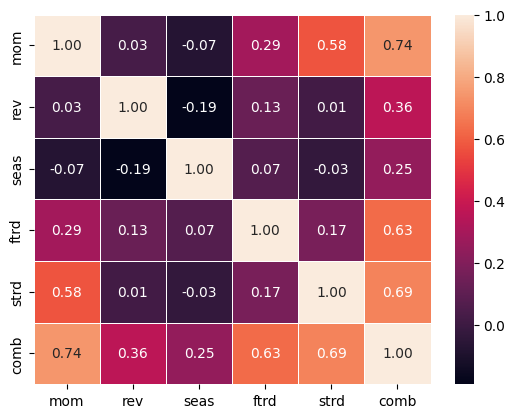

In [21]:
### correlations between return signals
sns.heatmap(pd.DataFrame(portfolios_ls).pct_change().corr(), 
            annot=True, fmt='.2f', linewidth=.5);

In [22]:
### seasonality of return signals
signal_season = pd.DataFrame()
for name, portfolio in portfolios_ls.items():
    tester = portfolio.pct_change().dropna()
    tester = tester.groupby(tester.index.month).mean()
    tester.name = name
    signal_season = pd.concat([signal_season, tester], axis=1)
signal_season = pd.concat([signal_season,pd.DataFrame(signal_season.std(),columns=['stdev']).T])
signal_season.index.name = 'month'
signal_season

,mom,rev,seas,ftrd,strd,comb
month,,,,,,
1,0.0037,-0.0059,0.0060,0.0073,0.0053,0.0030
2,0.0135,0.0035,0.0046,0.0097,0.0106,0.0090
3,0.0038,0.0095,0.0110,0.0090,0.0020,0.0069
4,-0.0063,-0.0004,0.0077,0.0019,-0.0048,-0.0012
5,0.0018,-0.0097,-0.0035,0.0072,0.0042,0.0022
6,0.0108,-0.0041,-0.0005,0.0027,0.0106,0.0050
7,0.0042,-0.0073,-0.0005,0.0042,0.0095,0.0025
8,0.0035,0.0001,0.0036,0.0101,0.0133,0.0068
9,0.0110,0.0084,0.0016,0.0134,0.0213,0.0118


In [23]:
### main results: long-short portfolios: full sample
stats_ls_full = pd.concat(
    [summary_stats(pd.DataFrame(portfolios_cost_ls)[:-5], factor_ret=sevenfactor),
     pd.DataFrame(pd.DataFrame(turnovers_ls)[:-5].mean(), columns=['avg_turnover']).T])
stats_ls_full

,mom,rev,seas,ftrd,strd,comb
nyears,52.1151,47.6082,42.6055,52.5342,51.6110,52.5342
nsamples,625,571,511,630,619,630
cagr,0.0387,-0.0126,0.0194,0.0539,0.0871,0.0534
mean,0.0500,-0.0033,0.0272,0.0633,0.0952,0.0558
mean-t-stat,2.2533,-0.1692,1.3214,2.9686,5.1323,4.6962
vol,0.1546,0.1380,0.1264,0.1477,0.1498,0.0851
skew,-0.0358,0.7913,0.1385,0.5931,-0.6074,0.5055
kurt,2.7234,2.9437,2.1040,3.1969,3.4808,6.3494
max,0.1989,0.2217,0.1801,0.2502,0.1669,0.1466
min,-0.2064,-0.1312,-0.1372,-0.1517,-0.2151,-0.1481


In [24]:
### main results: long-short portfolios: sample following the completion of all strategies
stats_ls_same = pd.concat(
    [summary_stats(pd.DataFrame(portfolios_cost_ls).dropna()[:-5], factor_ret=sevenfactor),
     pd.DataFrame(pd.DataFrame(turnovers_ls).dropna()[:-5].mean(), columns=['avg_turnover']).T])
stats_ls_same

,mom,rev,seas,ftrd,strd,comb
nyears,42.6055,42.6055,42.6055,42.6055,42.6055,42.6055
nsamples,511,511,511,511,511,511
cagr,0.0315,-0.0212,0.0194,0.0271,0.0788,0.0388
mean,0.0420,-0.0122,0.0272,0.0370,0.0864,0.0410
mean-t-stat,1.7294,-0.5929,1.3214,1.6738,4.3668,3.5640
vol,0.1482,0.1376,0.1264,0.1451,0.1432,0.0765
skew,0.1732,0.8352,0.1385,0.7217,-0.4509,0.9128
kurt,2.1595,3.2783,2.1040,4.3080,3.1878,6.0009
max,0.1989,0.2217,0.1801,0.2502,0.1669,0.1466
min,-0.1711,-0.1312,-0.1372,-0.1517,-0.2151,-0.0810


In [25]:
### main results: long-short portfolios: sample after GFC
stats_ls_same = pd.concat(
    [summary_stats(pd.DataFrame(portfolios_cost_ls).dropna()[:-5]['2011':], factor_ret=sevenfactor),
     pd.DataFrame(pd.DataFrame(turnovers_ls).dropna()[:-5]['2011':].mean(), columns=['avg_turnover']).T])
stats_ls_same

,mom,rev,seas,ftrd,strd,comb
nyears,14.5863,14.5863,14.5863,14.5863,14.5863,14.5863
nsamples,175,175,175,175,175,175
cagr,0.0201,-0.0711,0.0082,-0.0299,0.0441,0.0047
mean,0.0278,-0.0661,0.0144,-0.0193,0.0506,0.0069
mean-t-stat,0.8168,-2.1872,0.4768,-0.5265,1.8683,0.5062
vol,0.1269,0.1218,0.1115,0.1495,0.1208,0.0667
skew,0.6109,0.1489,-0.2882,0.2696,-0.7460,-0.1357
kurt,3.5543,0.9153,1.2540,3.2053,2.4736,4.1858
max,0.1860,0.0939,0.0873,0.1993,0.1251,0.0804
min,-0.1101,-0.1312,-0.1072,-0.1517,-0.1133,-0.0810


In [26]:
### main results: long-only portfolios: full sample
stats_lo_full = pd.concat(
    [summary_stats(pd.DataFrame(portfolios_cost_lo)[:-5], 
                   factor_ret=sevenfactor, bm_price=pd.DataFrame(portfolios_cost_lo)['bm']),
     pd.DataFrame(pd.DataFrame(turnovers_lo)[:-5].mean(), columns=['avg_turnover']).T])
stats_lo_full

,mom,rev,seas,ftrd,strd,comb,bm
nyears,52.1151,47.6082,42.6055,52.5342,51.6110,52.5342,52.5342
nsamples,625,571,511,630,619,630,630
cagr,0.0735,0.0568,0.0645,0.0796,0.0945,0.0779,0.0471
mean,0.0787,0.0595,0.0704,0.0825,0.0979,0.0798,0.0502
mean-t-stat,4.5672,4.4156,3.8105,4.9039,5.9810,5.9295,3.8917
vol,0.1227,0.0911,0.1241,0.1065,0.1194,0.0957,0.0907
skew,-0.5522,0.0684,-0.5165,0.2630,-0.8095,-0.2666,-0.8306
kurt,3.2489,1.2756,4.2382,2.1313,4.9041,1.2916,3.3312
max,0.1306,0.1138,0.1750,0.1577,0.1131,0.1016,0.0795
min,-0.1949,-0.1010,-0.2059,-0.1011,-0.2149,-0.1280,-0.1575


In [27]:
### main results: long-only portfolios: sample following the completion of all strategies
stats_lo_same = pd.concat(
    [summary_stats(pd.DataFrame(portfolios_cost_lo).dropna()[:-5], 
                   factor_ret=sevenfactor, bm_price=pd.DataFrame(portfolios_cost_lo)['bm']),
     pd.DataFrame(pd.DataFrame(turnovers_lo).dropna()[:-5].mean(), columns=['avg_turnover']).T])
stats_lo_same

,mom,rev,seas,ftrd,strd,comb,bm
nyears,42.6055,42.6055,42.6055,42.6055,42.6055,42.6055,42.6055
nsamples,511,511,511,511,511,511,511
cagr,0.0782,0.0553,0.0645,0.0724,0.0968,0.0774,0.0536
mean,0.0824,0.0578,0.0704,0.0753,0.0994,0.0789,0.0562
mean-t-stat,4.4818,4.1495,3.8105,4.0945,5.6385,5.4072,4.0478
vol,0.1164,0.0880,0.1241,0.1029,0.1154,0.0908,0.0886
skew,-0.4629,0.0114,-0.5165,0.0844,-0.5633,-0.2946,-0.9130
kurt,2.4724,1.5618,4.2382,2.2049,3.2168,0.5684,4.0148
max,0.1264,0.1138,0.1750,0.1577,0.1062,0.0973,0.0795
min,-0.1612,-0.1010,-0.2059,-0.1011,-0.2005,-0.0944,-0.1575


In [28]:
### main results: long-only portfolios: sample after GFC 
stats_lo_same = pd.concat(
    [summary_stats(pd.DataFrame(portfolios_cost_lo).dropna()[:-5]['2011':], 
                   factor_ret=sevenfactor, bm_price=pd.DataFrame(portfolios_cost_lo)['bm']),
     pd.DataFrame(pd.DataFrame(turnovers_lo).dropna()[:-5]['2011':].mean(), columns=['avg_turnover']).T])
stats_lo_same

,mom,rev,seas,ftrd,strd,comb,bm
nyears,14.5863,14.5863,14.5863,14.5863,14.5863,14.5863,14.5863
nsamples,175,175,175,175,175,175,175
cagr,0.0846,0.0279,0.0710,0.0437,0.0790,0.0648,0.0538
mean,0.0866,0.0313,0.0764,0.0473,0.0820,0.0667,0.0564
mean-t-stat,2.9535,1.7571,3.3528,1.4472,3.4132,3.2122,3.0645
vol,0.1020,0.0863,0.1229,0.0950,0.1070,0.0866,0.0885
skew,-0.0278,-0.1978,-0.5618,-0.2622,-0.4902,-0.3531,-0.5118
kurt,1.4225,3.4938,3.0180,1.0829,0.8733,0.1161,1.7951
max,0.1264,0.1138,0.1086,0.0911,0.0841,0.0785,0.0716
min,-0.0828,-0.1010,-0.1606,-0.0793,-0.1130,-0.0679,-0.1025


In [29]:
### main results: regression of signal portfolios on seven factors: long-short portfolios: full sample
ff7_name = ['MKT','SMB','HML','RMW','CMA','TERM','DEF']

ff7_ls_data = pd.DataFrame(portfolios_cost_ls).pct_change().join(sevenfactor)
ff7_ls = {}
for pf in pd.DataFrame(portfolios_cost_ls).columns:
    y = ff7_ls_data[pf].dropna()
    X = ff7_ls_data[ff7_name].loc[y.index].dropna()
    y = y.loc[X.index]
    ff7_ls[pf] = pd.DataFrame(factor_reg(X, y),
                              index=['coef','tval','pval'],
                              columns=['alpha','MKT','SMB','HML','RMW','CMA','TERM','DEF'])

ff7_ls = [df.unstack() for df in ff7_ls.values()]
ff7_ls = pd.concat(ff7_ls, axis=1, keys=pd.DataFrame(portfolios_cost_ls).columns)
ff7_ls

mom     rev    seas    ftrd    strd    comb
alpha coef  0.0043  0.0013  0.0029  0.0066  0.0070  0.0053
      tval  2.2731  0.9792  1.5432  3.5386  4.0743  5.3942
      pval  0.0230  0.3275  0.1228  0.0004  0.0000  0.0000
MKT   coef -0.0386 -0.3976  0.0541 -0.1437  0.2022 -0.0712
      tval -0.3736 -5.1380  1.0484 -2.3035  1.6790 -1.3846
      pval  0.7087  0.0000  0.2945  0.0213  0.0931  0.1662
SMB   coef  0.0990  0.0170 -0.0509 -0.0512  0.0687 -0.0148
      tval  1.0520  0.2786 -0.7925 -0.8322  0.8748 -0.3349
      pval  0.2928  0.7806  0.4281  0.4053  0.3817  0.7377
HML   coef -0.1807 -0.0592  0.0029 -0.0766 -0.2723 -0.1171
      tval -1.1980 -1.0806  0.0391 -0.9596 -1.7882 -1.7096
      pval  0.2309  0.2799  0.9688  0.3373  0.0737  0.0873
RMW   coef -0.0145  0.0164 -0.1652 -0.0869 -0.0038 -0.0688
      tval -0.0947  0.2247 -1.8429 -1.0202 -0.0271 -1.0788
      pval  0.9245  0.8222  0.0653  0.3076  0.9784  0.2807
CMA   coef  0.3806  0.5180 -0.2399  0.1641  0.4885  0.2701
      tval  1.6204  3.7933 -2.2050  1.2275  2.4457  2.7070
      pval  0.1051  0.0001  0.0275  0.2196  0.0145  0.0068
TERM  coef -0.0863  0.0913 -0.0067 -0.0536 -0.2539 -0.0777
      tval -0.8254  1.0124 -0.0830 -0.5739 -2.4488 -1.6013
      pval  0.4091  0.3113  0.9339  0.5660  0.0143  0.1093
DEF   coef -0.5352  0.0101  0.1229 -0.2272 -0.7679 -0.2878
      tval -2.6038  0.0641  0.9310 -1.1847 -4.0594 -3.5547
      pval  0.0092  0.9489  0.3519  0.2361  0.0000  0.0004

In [30]:
### main results: regression of signal portfolios on seven factors: long-only portfolios: full sample
ff7_lo_data = pd.DataFrame(portfolios_cost_lo).pct_change().join(sevenfactor)
ff7_lo = {}
for pf in pd.DataFrame(portfolios_cost_lo).columns:
    y = ff7_lo_data[pf].dropna()
    X = ff7_lo_data[ff7_name].loc[y.index].dropna()
    y = y.loc[X.index]
    ff7_lo[pf] = pd.DataFrame(factor_reg(X, y),
                              index=['coef','tval','pval'],
                              columns=['alpha','MKT','SMB','HML','RMW','CMA','TERM','DEF'])

ff7_lo = [df.unstack() for df in ff7_lo.values()]
ff7_lo = pd.concat(ff7_lo, axis=1, keys=pd.DataFrame(portfolios_cost_lo).columns)
ff7_lo

mom     rev    seas    ftrd    strd    comb      bm
alpha coef  0.0032  0.0024  0.0025  0.0043  0.0042  0.0039  0.0010
      tval  2.4626  2.5434  2.1463  3.8565  3.9432  4.6087  1.5466
      pval  0.0138  0.0110  0.0318  0.0001  0.0001  0.0000  0.1220
MKT   coef  0.4013  0.2225  0.4378  0.3306  0.5049  0.3674  0.4025
      tval  6.7034  4.9051 11.3059  8.5501  7.5612 10.1366 18.3149
      pval  0.0000  0.0000  0.0000  0.0000  0.0000  0.0000  0.0000
SMB   coef  0.1434  0.0722  0.0294  0.0483  0.1141  0.0600  0.0738
      tval  2.4209  2.0945  0.7995  1.1760  2.0695  1.5460  3.0507
      pval  0.0155  0.0362  0.4240  0.2396  0.0385  0.1221  0.0023
HML   coef -0.1158 -0.0329  0.0224 -0.0280 -0.1370 -0.0547  0.0104
      tval -1.4859 -0.8470  0.4321 -0.6957 -2.0387 -1.4398  0.3659
      pval  0.1373  0.3970  0.6657  0.4866  0.0415  0.1499  0.7145
RMW   coef -0.1128 -0.1349 -0.2086 -0.1264 -0.0806 -0.1519 -0.0830
      tval -1.1835 -3.4525 -3.8869 -2.7010 -0.9856 -3.1631 -2.8600
      pval  0.2366  0.0006  0.0001  0.0069  0.3244  0.0016  0.0042
CMA   coef  0.2427  0.2443 -0.0818  0.1159  0.2928  0.1626  0.0335
      tval  1.8133  3.3856 -1.1822  1.5662  2.5899  2.2344  0.8354
      pval  0.0698  0.0007  0.2371  0.1173  0.0096  0.0255  0.4035
TERM  coef  0.2177  0.2541  0.2601  0.2125  0.1160  0.1966  0.2391
      tval  3.4683  4.9195  5.4491  4.2209  2.1289  5.9785 13.9892
      pval  0.0005  0.0000  0.0000  0.0000  0.0333  0.0000  0.0000
DEF   coef  0.0528  0.3248  0.4606  0.1821 -0.0828  0.1700  0.2955
      tval  0.3883  3.5273  6.6479  1.6741 -0.7208  2.4397  7.2245
      pval  0.6978  0.0004  0.0000  0.0941  0.4711  0.0147  0.0000

In [31]:
picks_ls = pd.DataFrame({k: portfolios_cost_ls[k] for k in ['mom','rev','seas','ftrd','strd','comb']})
picks_lo = pd.DataFrame({k: portfolios_cost_lo[k] for k in ['mom','rev','seas','ftrd','strd','comb','bm']})

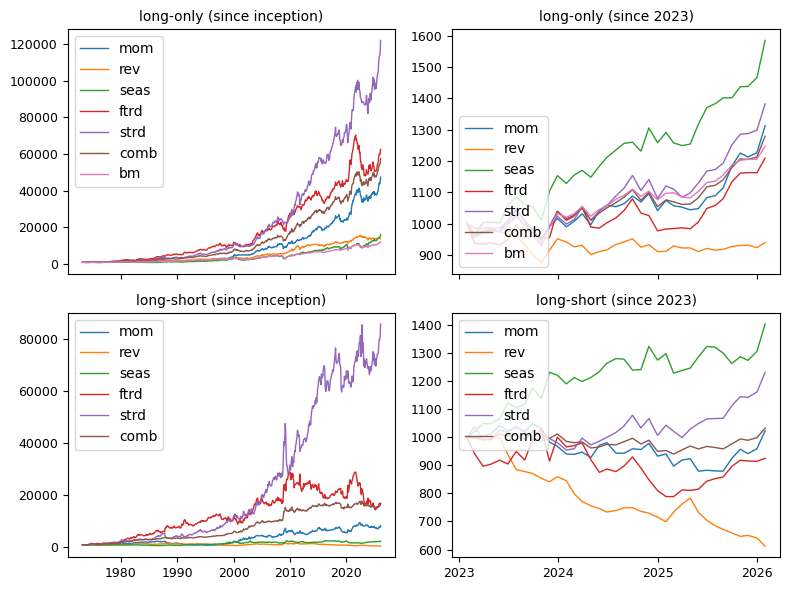

In [32]:
custom_start_year = '2023'

fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(nrows=2, ncols=2, figsize=(8, 6), sharex='col')

ax1.plot(rebase(picks_lo), label=picks_lo.columns, linewidth=1)
ax1.set_title('long-only (since inception)', fontsize=10)
ax1.legend(loc='upper left')
ax1.tick_params(axis='both', labelsize=9)

ax2.plot(rebase(picks_lo, custom_start_year), label=picks_lo.columns, linewidth=1)
ax2.set_title(f'long-only (since {custom_start_year})', fontsize=10)
ax2.legend(loc='lower left')
ax2.tick_params(axis='both', labelsize=9)

ax3.plot(rebase(picks_ls), label=picks_ls.columns, linewidth=1)
ax3.set_title('long-short (since inception)', fontsize=10)
ax3.legend(loc='upper left')
ax3.tick_params(axis='both', labelsize=9)
ax3.xaxis.set_major_locator(mdates.YearLocator(base=10))
ax3.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

ax4.plot(rebase(picks_ls, custom_start_year), label=picks_ls.columns, linewidth=1)
ax4.set_title(f'long-short (since {custom_start_year})', fontsize=10)
ax4.legend(loc='upper left')
ax4.tick_params(axis='both', labelsize=9)
ax4.xaxis.set_major_locator(mdates.YearLocator())
ax4.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.tight_layout()
plt.show()

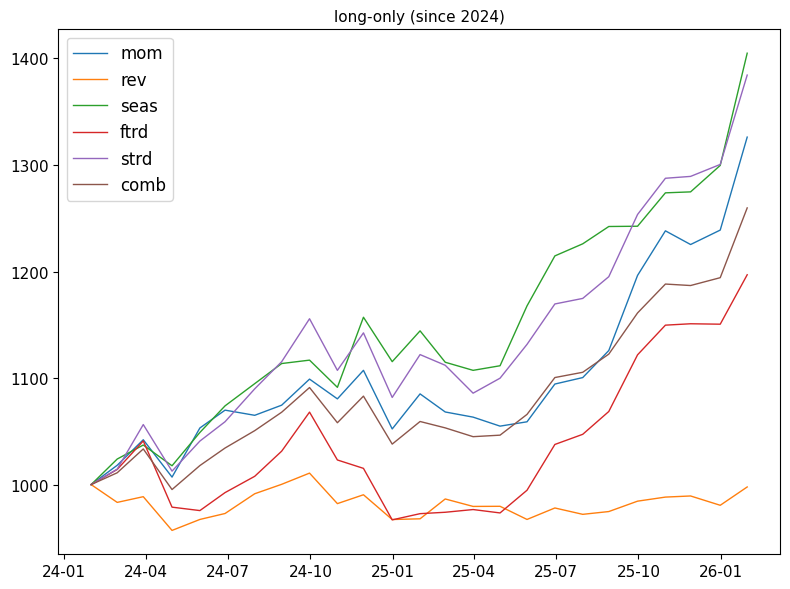

In [33]:
picks_lo_picks = picks_lo[['mom','rev','seas','ftrd','strd','comb']]

custom_start_year = '2024'

fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(8, 6))
ax.plot(rebase(picks_lo_picks, custom_start_year), label=picks_lo_picks.columns, linewidth=1)
ax.set_title(f'long-only (since {custom_start_year})', fontsize=11)
ax.legend(loc='upper left', fontsize=12)
ax.tick_params(axis='both', labelsize=11)
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%y-%m'))

plt.tight_layout()
plt.show()

In [34]:
risk_return_df = stats_lo_same.loc[['mean','vol']].join(asset_stats.loc[['mean','vol']]).T
risk_return_df = risk_return_df.apply(pd.to_numeric, errors='coerce')

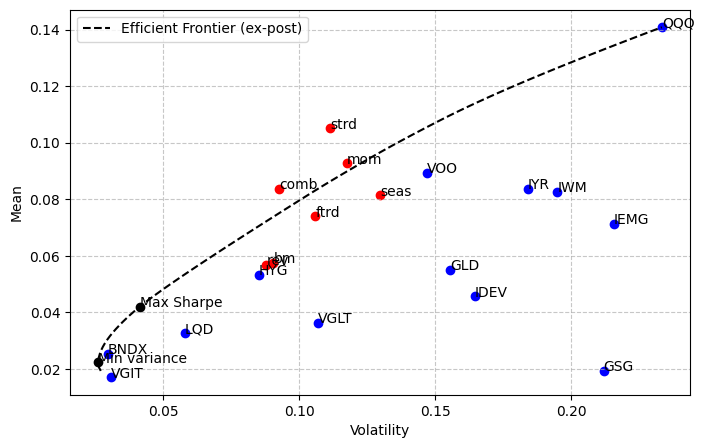

In [35]:
mu = price.pct_change().dropna().mean().mul(12).values
Sigma = price.pct_change().dropna().cov().mul(12).values
Sigma_sqrt = sqrtm(Sigma)
n_assets = len(mu)

# minumum-variance portfolio
w_minvar = cp.Variable(n_assets)
risk_minvar = cp.quad_form(w_minvar, Sigma)
prob_minvar = cp.Problem(cp.Minimize(risk_minvar), [cp.sum(w_minvar)==1, w_minvar>=0])
prob_minvar.solve()
w_minvar = w_minvar.value
ret_minvar = mu @ w_minvar
vol_minvar = np.sqrt(w_minvar.T @ Sigma @ w_minvar)

# maximum-Sharpe portfolio
y = cp.Variable(n_assets)
tau = 0.01
g = cp.Variable(nonneg=True)
k = cp.Variable(1, nonneg=True)
ret_sharpe = mu @ y
risk_sharpe = g
constraints = [cp.SOC(g, Sigma_sqrt @ y), ret_sharpe-tau*k==1, cp.sum(y)==k, y>=0]
prob_sharpe = cp.Problem(cp.Minimize(risk_sharpe), constraints)
prob_sharpe.solve(solver=cp.SCS)
w_sharpe = y.value/k.value
ret_sharpe = mu @ w_sharpe
vol_sharpe = np.sqrt(w_sharpe.T @ Sigma @ w_sharpe)

# efficient frontier
target_rets = np.linspace(np.sort(mu)[1], mu.max(), 100)
efficient_risks = []
for target in target_rets:
    w = cp.Variable(n_assets)
    risk = cp.quad_form(w, Sigma)
    prob = cp.Problem(cp.Minimize(risk),
                      [cp.sum(w) == 1,
                       mu @ w == target,
                       w >= 0])
    prob.solve(solver=cp.SCS)
    if w.value is not None:
        portfolio_std = np.sqrt(w.value.T @ Sigma @ w.value)
        efficient_risks.append(portfolio_std)
    else:
        efficient_risks.append(np.nan)
asset_vols = np.sqrt(np.diag(Sigma))
asset_means = mu
same_start = price.pct_change().dropna().index[0]
strategy_names = pd.DataFrame(portfolios_cost_lo).columns
strategy_vols = pd.DataFrame(portfolios_cost_lo).pct_change()[same_start:].std().mul(np.sqrt(12)).values
strategy_means = pd.DataFrame(portfolios_cost_lo).pct_change()[same_start:].mean().mul(12).values

# visualize
plt.figure(figsize=(8, 5))
plt.plot(efficient_risks, target_rets, 'k--', label='Efficient Frontier (ex-post)')
plt.scatter(vol_minvar, ret_minvar, c='black')
plt.text(vol_minvar, ret_minvar, 'Min variance')
plt.scatter(vol_sharpe, ret_sharpe, c='black')
plt.text(vol_sharpe, ret_sharpe, 'Max Sharpe')
plt.scatter(asset_vols, asset_means, c='blue')
for i, name in enumerate(assets):
    plt.text(asset_vols[i], asset_means[i], name)
plt.scatter(strategy_vols, strategy_means, c='red')
for i, name in enumerate(strategy_names):
    plt.text(strategy_vols[i], strategy_means[i], name)
plt.xlabel('Volatility')
plt.ylabel('Mean')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [36]:
(weights_lo['comb'] - 1/13).tail()

,VOO,QQQ,IWM,IDEV,IEMG,VGIT,VGLT,LQD,HYG,BNDX,GSG,GLD,IYR
Date,,,,,,,,,,,,,
2025-09-30,0.0346,0.0846,0.0346,-0.0154,0.0346,-0.0269,0.0038,0.0038,0.0346,0.0038,-0.0154,0.0846,-0.0462
2025-10-31,0.0846,0.0846,0.0846,-0.0154,0.0346,0.0346,0.0038,0.0346,-0.0462,0.0346,-0.0154,-0.0154,-0.0269
2025-11-28,-0.0462,0.0038,0.0346,0.0346,0.0538,0.0346,0.0038,0.0346,-0.0154,-0.0269,0.0038,0.0846,-0.0462
2025-12-31,-0.0462,0.0538,0.0038,-0.0154,0.1346,0.0038,0.0038,0.0038,-0.0154,-0.0769,0.0038,0.0846,-0.0769
2026-01-30,-0.0154,-0.0154,0.0846,0.0346,0.0846,0.0038,0.0038,0.0038,0.0346,-0.0462,0.0346,0.0846,-0.0154


In [37]:
weights_lo['comb'].sum(axis=1)

Date
1973-02-28   0.7500
1973-03-30   1.0000
1973-04-30   1.2500
1973-05-31   0.7500
1973-06-29   0.7500
              ...  
2025-09-30   1.2154
2025-10-31   1.2769
2025-11-28   1.1538
2025-12-31   1.0615
2026-01-30   1.2769
Length: 636, dtype: float64

In [38]:
sns.color_palette('pastel')

[(0.6313725490196078, 0.788235294117647, 0.9568627450980393),
 (1.0, 0.7058823529411765, 0.5098039215686274),
 (0.5529411764705883, 0.8980392156862745, 0.6313725490196078),
 (1.0, 0.6235294117647059, 0.6078431372549019),
 (0.8156862745098039, 0.7333333333333333, 1.0),
 (0.8705882352941177, 0.7333333333333333, 0.6078431372549019),
 (0.9803921568627451, 0.6901960784313725, 0.8941176470588236),
 (0.8117647058823529, 0.8117647058823529, 0.8117647058823529),
 (1.0, 0.996078431372549, 0.6392156862745098),
 (0.7254901960784313, 0.9490196078431372, 0.9411764705882353)]

In [39]:
print(sns.color_palette("pastel").as_hex())

['#a1c9f4', '#ffb482', '#8de5a1', '#ff9f9b', '#d0bbff', '#debb9b', '#fab0e4', '#cfcfcf', '#fffea3', '#b9f2f0']


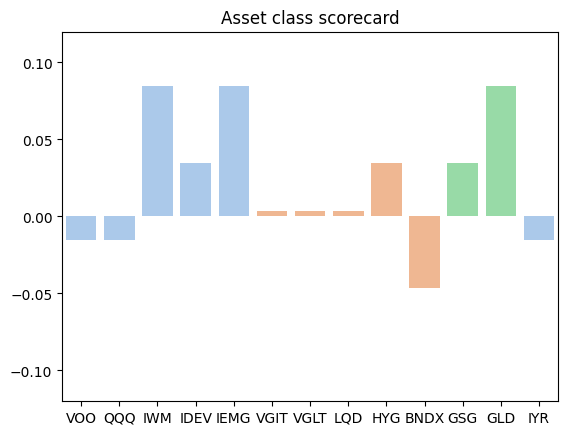

In [40]:
colors = ['#a1c9f4','#a1c9f4','#a1c9f4','#a1c9f4','#a1c9f4',
          '#ffb482','#ffb482','#ffb482','#ffb482','#ffb482',
          '#8de5a1','#8de5a1']
sns.barplot((weights_lo['comb'] - 1/13).tail(1), 
            palette=colors)
plt.title('Asset class scorecard')
plt.ylim(-0.12,0.12);

In [41]:
last_point = (pd.concat(weights_lo).xs(weights_lo['comb'].index[-1], level='Date') - 1/13)[:-1].T
last_point.columns = ['MOM','REV','SEAS','F-Trend','S-Trend','COMB']

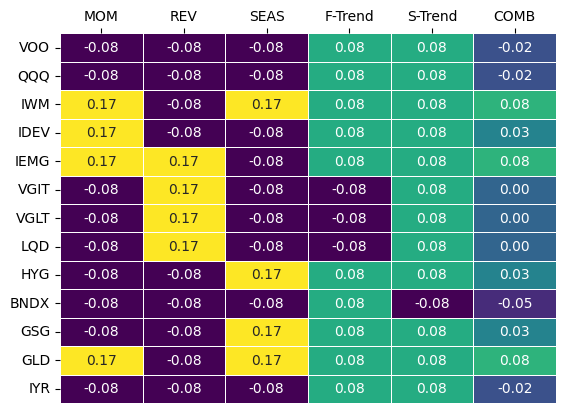

In [42]:
ax = sns.heatmap(last_point, fmt='.2f', cmap='viridis', annot=True, linewidth=.5, cbar=False)
ax.xaxis.tick_top()

In [43]:
# with pd.ExcelWriter('C:/Users/11120/Documents/Python/data/scorecard_res.xlsx', engine='openpyxl') as writer:
#     weights_lo['comb'].to_excel(writer, sheet_name='weight-lo')
#     picks_lo.to_excel(writer, sheet_name='port-lo')    
#     stats_lo_full.to_excel(writer, sheet_name='stats-lo')    
#     ff7_lo.to_excel(writer, sheet_name='alpha-test-lo')    

In [44]:
def allocationChart(df):
    group_labels = ['Global Equity','Global Bond','Alternatives']
    groups = {'Global Equity': df.iloc[:,:5].sum(axis=1),
              'Global Bond': df.iloc[:,5:10].sum(axis=1),
              'Alternatives': df.iloc[:,10:].sum(axis=1),}
    grouped_df = pd.DataFrame(groups)
    plt.figure(figsize=(8,4))
    plt.stackplot(grouped_df.index, grouped_df.T, labels=group_labels)  
    plt.legend(loc='lower left')
    plt.show()

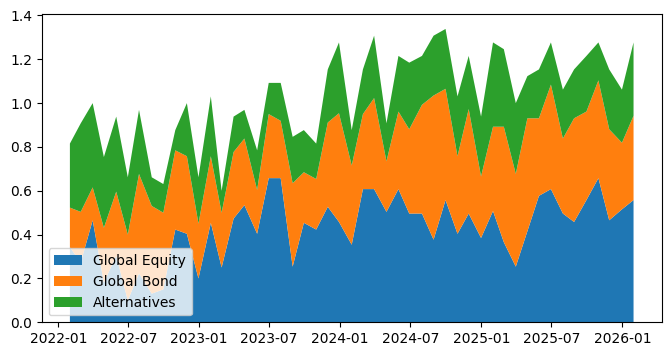

In [45]:
allocationChart(weights_lo['comb']['2022':])

In [46]:
signal_hist = weights_ls['comb'].rolling(1).mean()['2024-01-01':]

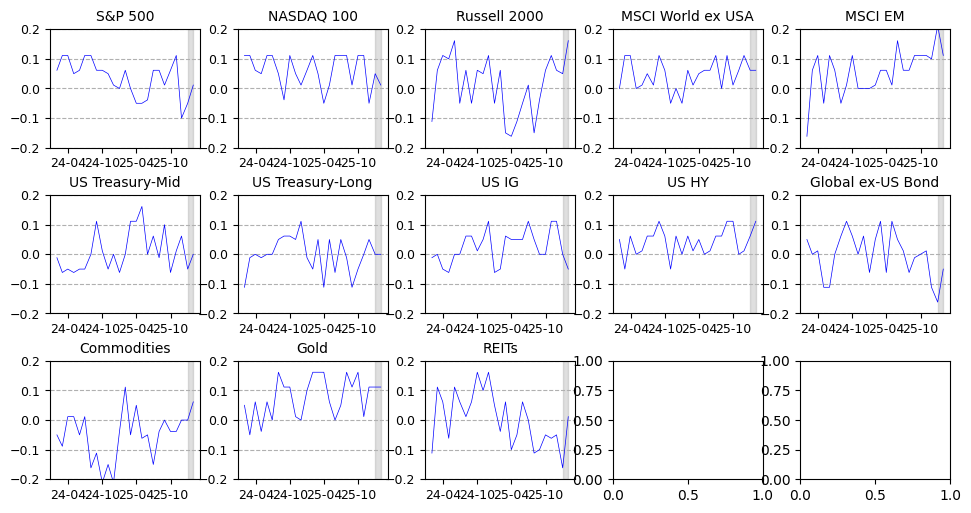

In [47]:
titles = ['S&P 500','NASDAQ 100','Russell 2000','MSCI World ex USA','MSCI EM','US Treasury-Mid','US Treasury-Long','US IG','US HY','Global ex-US Bond','Commodities','Gold','REITs']

fig, axs = plt.subplots(nrows=3, ncols=5, figsize=(10, 5))
axs = axs.flatten()
for i, pred in enumerate(signal_hist):
    ax = axs[i]
    ax.plot(signal_hist.index, signal_hist[pred], color='blue', linewidth=0.5)
    ax.set_title(titles[i], fontsize=10)
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%y-%m'))
    ax.set_ylim(-0.2,0.2)
    ax.tick_params(axis='x', labelsize=9)
    ax.tick_params(axis='y', labelsize=9)
    ax.grid(axis='y', linestyle='--')

    start = signal_hist.index[-2]
    end   = signal_hist.index[-1]
    ax.axvspan(start, end, color='gray', alpha=0.25)
# for j in range(len(signal_hist), 12):
#     fig.delaxes(axs[j])
plt.subplots_adjust(left=0.05, right=0.95, bottom=0.05, top=0.95, wspace=0.25, hspace=0.4)

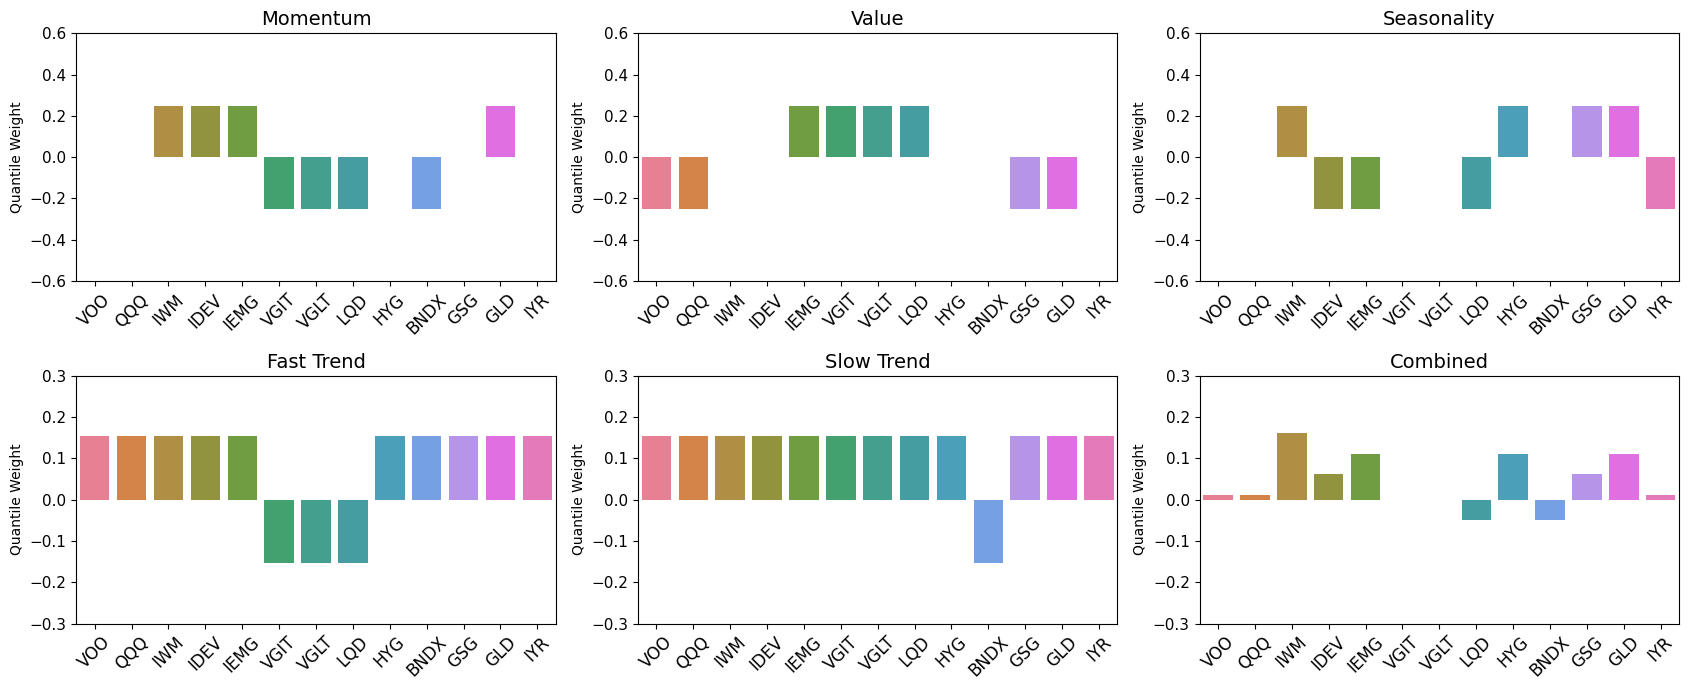

In [48]:
strategies = ['mom','rev','seas','ftrd','strd','comb']
strategy_names = {
    'mom': 'Momentum',
    'rev': 'Value', 
    'seas': 'Seasonality',
    'ftrd': 'Fast Trend',
    'strd': 'Slow Trend',
    'comb': 'Combined'
}

fig, axes = plt.subplots(2, 3, figsize=(17, 7)) 
axes = axes.flatten() 
for i, s in enumerate(strategies):
    sns.barplot(weights_ls[s].iloc[-1:], ax=axes[i])
    #sns.barplot(weights_ls[s].loc['2025-04-30'], ax=axes[i])
    axes[i].set_title(f'{strategy_names[s]}', fontsize=14)
    axes[i].set_ylabel('Quantile Weight')
    if i == 5: 
        axes[i].set_ylim(-0.3, 0.3)
    elif i >= 3 and i <=4: 
        axes[i].set_ylim(-0.3, 0.3)
    else:
        axes[i].set_ylim(-0.6, 0.6)
    axes[i].tick_params(axis='x', rotation=45, labelsize=12)
    axes[i].tick_params(axis='y', labelsize=11)
plt.tight_layout()
plt.show()

### 4. Robustness Checks: Long-only portfolios

#### 4.1. Model specifications

In [49]:
### different ranking and holding periods: individual signals
momps = [3,6,9]
revps = [36,60,120]
seasps = [120,180,240]
ftrdps = [1,2,3]
strdps = [10,11,12]
holding_moms = [1,6,12,24,60]
holding_revs = [1,6,12,24,60]
holding_seass = [1,6,12,24,60]
holding_ftrds = [1,6,12,24,60]
holding_strds = [1,6,12,24,60]
# other specifications: follow the main model spec
method = 'quantile'
quantile = 'tercile'
tcost = 0.000

In [50]:
from itertools import product

test_spec = {}
sig_names = ['mom','rev','seas','ftrd','strd']
sig_ranks = [momps,revps,seasps,ftrdps,strdps]
sig_holds = [holding_moms,holding_revs,holding_seass,holding_ftrds,holding_strds]

for i, (sig_name, sig_rank, sig_hold) in enumerate(zip(sig_names, sig_ranks, sig_holds)):
    test_spec[sig_name] = pd.DataFrame(
        index=pd.MultiIndex.from_product(
            [sig_rank, ['nsamples','ir','alpha','alpha-t-stat']]), columns=sig_hold)
    spec_grid = list(product(sig_rank, sig_hold))
    for r, h in spec_grid:
        if sig_name == 'mom':
            sig = generate_signal(ret,momp=r)[i]
        elif sig_name == 'rev':
            sig = generate_signal(ret,revp=r)[i]
        elif sig_name == 'seas':
            sig = generate_signal(ret,seasp=r)[i]
        elif sig_name == 'ftrd':
            sig = generate_signal(ret,ftrdp=r)[i]
        elif sig_name == 'strd':
            sig = generate_signal(ret,strdp=r)[i]
            
        if sig_name in ['mom','rev','seas']:
            sig_ls_wgt, sig_lo_wgt = generate_cs_weight(
                sig,method=method,quantile=quantile,holding=h)
        else:
            sig_ls_wgt, sig_lo_wgt = generate_ts_weight(sig,holding=h)
            
        sig_pf, sig_cost, sig_turn = generate_portfolio(ret, sig_lo_wgt, tcost=tcost)
        bm_wgt = ret.loc[sig_lo_wgt.index]
        bm_wgt = bm_wgt.apply(lambda row: row.where(row.isna(), 1/row.notna().sum()).fillna(0), axis=1)
        bm_pf, bm_cost, bm_turn = generate_portfolio(ret, bm_wgt, tcost=tcost)
        test_spec[sig_name].loc[r,h] = summary_stats(
            pd.DataFrame(sig_pf)[:-2], factor_ret=sevenfactor, bm_price=bm_pf
        ).loc[['nsamples','ir','alpha','alpha-t-stat']].values

In [51]:
test_spec['mom']

1      6      12     24     60
3 nsamples        631    626    620    608    572
  ir           0.4466 0.2603 0.4546 0.3349 0.2732
  alpha        0.0509 0.0212 0.0248 0.0154 0.0110
  alpha-t-stat 3.2335 1.7538 2.3240 1.4893 1.1838
6 nsamples        628    623    617    605    569
  ir           0.4327 0.4306 0.3921 0.2992 0.2398
  alpha        0.0444 0.0337 0.0296 0.0190 0.0126
  alpha-t-stat 2.8453 2.3969 2.2868 1.6716 1.2407
9 nsamples        625    620    614    602    566
  ir           0.4676 0.5448 0.3790 0.3039 0.2466
  alpha        0.0507 0.0464 0.0308 0.0224 0.0147
  alpha-t-stat 3.1355 3.3769 2.3933 1.7830 1.3835

In [52]:
test_spec['rev']

1       6       12      24      60
36  nsamples         598     593     587     575     539
    ir           -0.2915 -0.2333 -0.2080 -0.1647 -0.2043
    alpha        -0.0068  0.0037  0.0088  0.0121  0.0103
    alpha-t-stat -0.5390  0.2941  0.7375  1.0894  1.0338
60  nsamples         574     569     563     551     515
    ir           -0.1694 -0.1198 -0.1014 -0.0549 -0.1786
    alpha         0.0078  0.0147  0.0142  0.0153  0.0156
    alpha-t-stat  0.7326  1.3106  1.3145  1.4877  1.6550
120 nsamples         514     509     503     491     455
    ir           -0.0640 -0.0607 -0.0767 -0.0741 -0.1222
    alpha         0.0210  0.0244  0.0252  0.0302  0.0268
    alpha-t-stat  1.9161  2.1214  2.3095  2.7537  2.4642

In [53]:
test_spec['seas']

1       6       12      24      60
120 nsamples        514     509     503     491     455
    ir           0.4030  0.0802  0.0830  0.0549 -0.0313
    alpha        0.0440  0.0144  0.0115  0.0105  0.0020
    alpha-t-stat 3.2014  1.5061  1.2255  1.1521  0.2565
180 nsamples        454     449     443     431     395
    ir           0.1887 -0.2126 -0.2073 -0.1053  0.0411
    alpha        0.0263 -0.0060 -0.0069 -0.0051 -0.0044
    alpha-t-stat 1.9145 -0.7234 -0.7802 -0.5814 -0.4901
240 nsamples        394     389     383     371     335
    ir           0.5619  0.0768  0.1936  0.1637  0.1002
    alpha        0.0368 -0.0033 -0.0025 -0.0042 -0.0011
    alpha-t-stat 2.6105 -0.3800 -0.2615 -0.4456 -0.1185

In [54]:
test_spec['ftrd']

1      6      12     24     60
1 nsamples        633    628    622    610    574
  ir           0.5878 0.4444 0.6680 0.4711 0.3407
  alpha        0.0625 0.0204 0.0217 0.0104 0.0072
  alpha-t-stat 4.7072 2.3450 2.5629 1.2034 0.8686
2 nsamples        632    627    621    609    573
  ir           0.5118 0.4251 0.6155 0.4540 0.3871
  alpha        0.0485 0.0222 0.0232 0.0118 0.0076
  alpha-t-stat 4.3134 2.3937 2.5618 1.3256 0.8888
3 nsamples        631    626    620    608    572
  ir           0.5067 0.3684 0.5252 0.4088 0.3672
  alpha        0.0490 0.0232 0.0230 0.0119 0.0080
  alpha-t-stat 3.7305 2.2863 2.4494 1.2925 0.9370

In [55]:
test_spec['strd']

1      6      12     24     60
10 nsamples        624    619    613    601    565
   ir           0.5539 0.5285 0.3698 0.3029 0.3371
   alpha        0.0464 0.0363 0.0205 0.0118 0.0046
   alpha-t-stat 3.5315 2.9290 1.7368 1.0587 0.4788
11 nsamples        623    618    612    600    564
   ir           0.7056 0.5340 0.3540 0.3008 0.3508
   alpha        0.0567 0.0378 0.0197 0.0124 0.0060
   alpha-t-stat 4.4941 2.9588 1.6132 1.0950 0.6042
12 nsamples        622    617    611    599    563
   ir           0.6714 0.5110 0.3413 0.3001 0.3384
   alpha        0.0528 0.0364 0.0195 0.0125 0.0052
   alpha-t-stat 4.1358 2.8620 1.5933 1.0984 0.5224

In [56]:
### different ranking and holding periods: combined signals
holding_combs = [1,2,3,6,12,24,60]
# other specifications: follow the main model spec
momp = 6
momk = 0
revp = 60
revk = 12
seasp = 120
ftrdp = 1
strdp = 12
holding_mom = 1
holding_rev = 1
holding_seas = 1
holding_ftrd = 1
holding_strd = 1
method = 'quantile'
quantile = 'tercile'
tcost = 0.000

In [57]:
test_spec['comb'] = pd.DataFrame(index=['nsamples','ir','alpha','alpha-t-stat'], columns=holding_combs)
for holding_comb in holding_combs:
    weights_lo_, turnovers_lo_, portfolios_lo_, portfolios_cost_lo_ = generate_results(ret, 'lo')
    test_spec['comb'].loc[:,holding_comb] = summary_stats(
        pd.DataFrame(portfolios_lo_['comb'][:-2]), factor_ret=sevenfactor, 
        bm_price=portfolios_lo_['bm']).loc[['nsamples','ir','alpha','alpha-t-stat']].values.ravel()

In [58]:
test_spec['comb']

,1,2,3,6,12,24,60
nsamples,633,632,631,628,622,610,574
ir,0.7984,0.6531,0.5911,0.5151,0.4315,0.2510,0.1989
alpha,0.0517,0.0401,0.0366,0.0287,0.0246,0.0127,0.0094
alpha-t-stat,5.1390,4.1390,3.5926,2.9659,2.5281,1.3936,1.0431


In [59]:
### different weighting and grouping methods
methods = ['quantile', 'proportion', 'rank']
quantiles = ['median', 'tercile', 'quartile']
# other specifications: follow the main model spec
momp = 6
momk = 0
revp = 60
revk = 12
seasp = 120
ftrdp = 1
strdp = 12
holding_mom = 1
holding_rev = 1
holding_seas = 1
holding_ftrd = 1
holding_strd = 1
holding_comb = 1
tcost = 0.000

In [60]:
test_method = []
for method, quantile in product(methods, quantiles):
    if method in ['proportion', 'rank'] and quantile in ['tercile', 'quartile']:
        continue

    weights_lo_, turnovers_lo_, portfolios_lo_, portfolios_cost_lo_ = generate_results(ret,'lo')
    if method in ['proportion', 'rank']:
        test_method_ = pd.DataFrame(
            summary_stats(pd.DataFrame(portfolios_lo_['comb'][:-2]), factor_ret=sevenfactor,
                          bm_price=portfolios_lo_['bm']
                         ).loc[['nsamples','ir','alpha','alpha-t-stat']].values.reshape(1,-1),
            index=[f'{method}'], columns=['nsamples','ir','alpha','alpha-t-stat'])
    else:
        test_method_ = pd.DataFrame(
            summary_stats(pd.DataFrame(portfolios_lo_['comb'][:-2]), factor_ret=sevenfactor,
                          bm_price=portfolios_lo_['bm']
                         ).loc[['nsamples','ir','alpha','alpha-t-stat']].values.reshape(1,-1),
            index=[f'{method}-{quantile}'], columns=['nsamples','ir','alpha','alpha-t-stat'])
    test_method.append(test_method_)
test_method = pd.concat(test_method)

In [62]:
test_method

,nsamples,ir,alpha,alpha-t-stat
quantile-median,633,0.7476,0.0461,4.8278
quantile-tercile,633,0.7984,0.0517,5.1390
quantile-quartile,633,0.6890,0.0540,4.7848
proportion,633,0.6680,0.0531,4.6948
rank,633,0.7454,0.0444,4.6706


#### 4.2. Performance across different asset universes

In [63]:
### main model specification
# ranking and holding periods
momp = 6
momk = 0
revp = 60
revk = 12
seasp = 120
ftrdp = 1
strdp = 12
holding_mom = 1
holding_rev = 1
holding_seas = 1
holding_ftrd = 1
holding_strd = 1
holding_comb = 1
# weighting methods
method = 'quantile'
quantile = 'tercile'
# transaction costs
tcost = 0.000

In [64]:
import random

num_sampled_assets = 10
num_samples = 10

test_universe = {}
for i in range(num_samples):
    sampled_assets = random.sample(assets, num_sampled_assets)
    sampled_ret = ret[sampled_assets]
    
    weights_lo_, turnovers_lo_, portfolios_lo_, portfolios_cost_lo_ = generate_results(sampled_ret,'lo')
    res = summary_stats(pd.DataFrame(portfolios_lo_)[:-2].drop(columns=['bm']), 
                        factor_ret=sevenfactor, bm_price=pd.DataFrame(portfolios_lo_)['bm'])
    test_universe[i] = res.loc[['ir','alpha','alpha-t-stat']]
test_universe = pd.concat(test_universe)

In [65]:
test_universe.loc[pd.IndexSlice[:,'ir'],:]

,,mom,rev,seas,ftrd,strd,comb
0,ir,0.2924,-0.0740,0.3769,0.4703,0.6322,0.6600
1,ir,0.3063,0.1475,0.3643,0.6615,0.6649,0.7480
2,ir,0.4220,-0.0273,0.2707,0.5722,0.6327,0.6851
3,ir,0.3443,-0.0460,0.3141,0.6101,0.7149,0.7310
4,ir,0.5166,-0.0121,0.3672,0.5485,0.7512,0.7801
5,ir,0.4451,0.0069,0.2387,0.5724,0.7359,0.7371
6,ir,0.4262,-0.0319,0.3148,0.5347,0.6282,0.7012
7,ir,0.3256,-0.1668,0.3222,0.5287,0.6545,0.6778
8,ir,0.3869,0.0529,0.2373,0.5707,0.6147,0.6724
9,ir,0.4057,0.0310,0.2239,0.6092,0.6410,0.6857


#### 4.3. Subsamples

In [66]:
### main model specification
# ranking and holding periods
momp = 6
momk = 0
revp = 60
revk = 12
seasp = 120
ftrdp = 1
strdp = 12
holding_mom = 1
holding_rev = 1
holding_seas = 1
holding_ftrd = 1
holding_strd = 1
holding_comb = 1
# weighting methods
method = 'quantile'
quantile = 'tercile'
# transaction costs
tcost = 0.000

In [67]:
weights_lo, turnovers_lo, portfolios_lo, portfolios_cost_lo = generate_results(ret, 'lo')

In [68]:
pd.DataFrame(portfolios_lo).index.year.min()

1973

In [69]:
test_subsample = {}
start_years = [1970, 1980, 1990, 2000, 2010, 2020]
interval = 10

for start_year in start_years:    
    start_date = f'{start_year-1}-12-01'  # due to monthly month-end data
    end_date = f'{start_year+interval-1}-12-31'

    subsample = pd.DataFrame(portfolios_lo).loc[start_date:end_date]
    test_subsample[f'{start_year}'] = summary_stats(
        subsample[:-2].drop(columns=['bm']), 
        factor_ret=sevenfactor, bm_price=subsample['bm']).loc[['ir','alpha','alpha-t-stat']]
test_subsample = pd.concat(test_subsample)

In [70]:
test_subsample

mom     rev    seas    ftrd    strd    comb
1970 ir            0.4658  0.5967     NaN  0.9938  1.1138  0.9313
     alpha         0.0459  0.1285     NaN  0.0865  0.0789  0.0748
     alpha-t-stat  0.8577  2.0595     NaN  2.8459  1.6898  2.0497
1980 ir            0.1371  0.1460 -0.1218  1.1229  0.4142  0.7874
     alpha        -0.0355  0.0178  0.0435  0.1090 -0.0154  0.0184
     alpha-t-stat -1.2274  0.8020  1.4218  3.5851 -0.4230  0.8447
1990 ir            0.2549 -0.0265  0.7872  0.5382  0.8284  0.9727
     alpha         0.0103  0.0403  0.0536  0.0268  0.0329  0.0328
     alpha-t-stat  0.3897  2.0359  2.5567  1.0501  1.7413  2.2290
2000 ir            0.6574  0.4050  0.1868  0.7379  0.6022  0.9247
     alpha         0.0624  0.0516  0.0770  0.0852  0.0712  0.0695
     alpha-t-stat  2.1111  2.1639  2.8167  3.0668  3.2739  3.9327
2010 ir            0.2265 -0.1513  0.5364 -0.0679  0.6962  0.4542
     alpha        -0.0270 -0.0124 -0.0177 -0.0176 -0.0216 -0.0193
     alpha-t-stat -1.2947 -0.7736 -1.0793 -0.9119 -1.7926 -1.8980
2020 ir            0.8129 -0.4391  0.3505  0.0818  0.3147  0.4096
     alpha         0.0568  0.0172  0.0174  0.0306  0.0244  0.0293
     alpha-t-stat  1.9000  0.8021  0.4943  0.6695  1.4160  2.3191

#### 4.4. Transaction costs

In [71]:
### account for transaction costs
tcosts = [0.000,0.001,0.002,0.003,0.004,0.005]  # one-way costs
# other specifications: follow the main model spec
momp = 6
momk = 0
revp = 60
revk = 12
seasp = 120
ftrdp = 1
strdp = 12
holding_mom = 1
holding_rev = 1
holding_seas = 1
holding_ftrd = 1
holding_strd = 1
holding_comb = 1
method = 'quantile'
quantile = 'tercile'

In [72]:
test_tcost = {}
for tcost in tcosts:
    weights_lo_, turnovers_lo_, portfolios_lo_, portfolios_cost_lo_ = generate_results(ret,'lo')
    res = pd.concat(
        [summary_stats(pd.DataFrame(portfolios_cost_lo_)[:-2].drop(columns=['bm']), 
                       factor_ret=sevenfactor, bm_price=portfolios_cost_lo_['bm']),
         pd.DataFrame(pd.DataFrame(turnovers_lo_)[:-2].drop(columns=['bm']).mean(), 
                      columns=['avg_turnover']).T])
    test_tcost[f'{tcost*100}%'] = res.loc[['ir','alpha','alpha-t-stat']]
test_tcost = pd.concat([pd.concat(test_tcost), res.loc[['avg_turnover','nsamples']]])

In [73]:
test_tcost

,mom,rev,seas,ftrd,strd,comb
"(0.0%, ir)",0.4327,0.0852,0.4030,0.5878,0.6714,0.7984
"(0.0%, alpha)",0.0444,0.0309,0.0440,0.0625,0.0528,0.0517
"(0.0%, alpha-t-stat)",2.8453,2.7259,3.2014,4.7072,4.1358,5.1390
"(0.1%, ir)",0.3626,0.0627,0.1949,0.4436,0.6428,0.6802
"(0.1%, alpha)",0.0383,0.0290,0.0289,0.0515,0.0504,0.0462
"(0.1%, alpha-t-stat)",2.4417,2.5538,2.0979,3.8482,3.9250,4.5865
"(0.2%, ir)",0.2924,0.0402,-0.0132,0.2993,0.6140,0.5620
"(0.2%, alpha)",0.0323,0.0270,0.0139,0.0405,0.0479,0.0407
"(0.2%, alpha-t-stat)",2.0424,2.3811,1.0018,3.0012,3.7160,4.0347
"(0.3%, ir)",0.2223,0.0177,-0.2209,0.1551,0.5853,0.4437


### 5. Driving Forces: Long-short portfolios

In [74]:
### main model specification
# ranking and holding periods
momp = 6
momk = 0
revp = 60
revk = 12
seasp = 120
ftrdp = 1
strdp = 12
holding_mom = 1
holding_rev = 1
holding_seas = 1
holding_ftrd = 1
holding_strd = 1
holding_comb = 1
# weighting methods
method = 'quantile'
quantile = 'tercile'
# transaction costs
tcost = 0.000

In [75]:
(weights_ls, turnovers_ls, portfolios_ls, portfolios_cost_ls, 
 weights_lo, turnovers_lo, portfolios_lo, portfolios_cost_lo) = generate_results(ret)

In [76]:
signals = ['mom','rev','seas','ftrd','strd','comb']

#### 5.1. Market states

In [77]:
### up versus down markets (Cooper, Gutierrez, and Hameed (2004))
#mkt_state_data = pd.DataFrame(portfolios_lo).pct_change().join(mkt).drop(['bm'], axis=1)
mkt_state_data = pd.DataFrame(portfolios_ls).pct_change().join(mkt)
mkt_state = {}
for signal in signals: 
    sample = mkt_state_data[[signal,'up_state','down_state']].dropna()
    y = sample[signal]
    X = sample[['up_state','down_state']]
    model = sm.OLS(y, X)
    res = model.fit(cov_type='HAC',cov_kwds={'maxlags':12})  # Newey and West (1987)
    m0, m1 = res.params
    se0, se1 = res.bse
    t0, t1 = res.tvalues
    p0, p1 = res.pvalues
    m2 = m0 - m1
    t2 = m2 / np.sqrt(se0**2 + se1**2)
    p2 = 2*(1-stats.t.cdf(abs(t2), df=res.df_resid-2))    
    mkt_state[signal] = pd.DataFrame([[m0*12, m1*12, m2*12],[t0,t1,t2],[p0,p1,p2]],
                                     index=['coef','tval','pval'],
                                     columns=['up_state','down_state','diff'])

In [78]:
pd.concat(mkt_state)

up_state  down_state    diff
mom  coef    0.0627      0.0706 -0.0079
     tval    2.5285      1.2849 -0.1313
     pval    0.0115      0.1988  0.8955
rev  coef   -0.0138      0.0856 -0.0994
     tval   -0.7377      1.4589 -1.6142
     pval    0.4607      0.1446  0.1070
seas coef    0.0518      0.0886 -0.0368
     tval    2.5172      1.3955 -0.5517
     pval    0.0118      0.1629  0.5814
ftrd coef    0.0617      0.1931 -0.1314
     tval    2.7606      3.3236 -2.1118
     pval    0.0058      0.0009  0.0351
strd coef    0.0970      0.1201 -0.0231
     tval    4.9604      2.0042 -0.3664
     pval    0.0000      0.0450  0.7142
comb coef    0.0544      0.1182 -0.0638
     tval    4.9836      2.8286 -1.4776
     pval    0.0000      0.0047  0.1400

In [79]:
### high versus low volatility (Wang and Xu (2015))
#vol_state_data = pd.DataFrame(portfolios_lo).pct_change().join(vol).drop(['bm'], axis=1)
vol_state_data = pd.DataFrame(portfolios_ls).pct_change().join(vol)
vol_state = {}
for signal in signals: 
    sample = vol_state_data[[signal,'hivol_state','lovol_state']].dropna()
    y = sample[signal]
    X = sample[['hivol_state','lovol_state']]
    model = sm.OLS(y, X)
    res = model.fit(cov_type='HAC',cov_kwds={'maxlags':12})  # Newey and West (1987)
    m0, m1 = res.params
    se0, se1 = res.bse
    t0, t1 = res.tvalues
    p0, p1 = res.pvalues
    m2 = m0 - m1
    t2 = m2 / np.sqrt(se0**2 + se1**2)
    p2 = 2*(1-stats.t.cdf(abs(t2), df=res.df_resid-2))    
    vol_state[signal] = pd.DataFrame([[m0*12, m1*12, m2*12],[t0,t1,t2],[p0,p1,p2]],
                                     index=['coef','tval','pval'],
                                     columns=['hivol_state','lovol_state','diff'])

In [80]:
pd.concat(vol_state)

hivol_state  lovol_state    diff
mom  coef       0.0865       0.0439  0.0426
     tval       2.2599       2.2071  0.9884
     pval       0.0238       0.0273  0.3233
rev  coef       0.0079      -0.0062  0.0141
     tval       0.2368      -0.2997  0.3588
     pval       0.8128       0.7644  0.7198
seas coef       0.0796       0.0390  0.0406
     tval       2.1165       2.1502  0.9726
     pval       0.0343       0.0315  0.3312
ftrd coef       0.1386       0.0395  0.0991
     tval       4.1794       1.6885  2.4428
     pval       0.0000       0.0913  0.0148
strd coef       0.0688       0.1305 -0.0617
     tval       2.1225       6.7049 -1.6327
     pval       0.0338       0.0000  0.1030
comb coef       0.0772       0.0567  0.0204
     tval       3.7881       4.7235  0.8643
     pval       0.0002       0.0000  0.3877

#### 5.2. Business cycle

In [81]:
### research design: Petkova and Zhang (2005)
### the estimated expected market risk premium 
emrp_data = macrofactor.join(fivefactor[['MKT']])
y = emrp_data['MKT']
X = emrp_data.drop(['MKT'], axis=1)
X = sm.add_constant(X)
model = sm.OLS(y, X)
res = model.fit(cov_type='HAC',cov_kwds={'maxlags':12}) 
emrp = pd.DataFrame(res.fittedvalues, columns=['EMRP'])

In [82]:
print(res.summary())

ValueError: r_matrix performs f_test for using dimensions that are asymptotically non-normal

In [83]:
upper_10 = np.percentile(emrp['EMRP'], 90)
avg = np.mean(emrp['EMRP'])
lower_10 = np.percentile(emrp['EMRP'], 10)

emrp['peak'] = (emrp['EMRP'] <= lower_10).astype(int)
emrp['expansion'] = ((emrp['EMRP'] > lower_10) & (emrp['EMRP'] < avg)).astype(int)
emrp['recession'] = ((emrp['EMRP'] > avg) & (emrp['EMRP'] < upper_10)).astype(int)
emrp['trough'] = (emrp['EMRP'] >= upper_10).astype(int)
emrp['non-trough'] = (emrp['EMRP'] < upper_10).astype(int)

In [84]:
cycles = emrp.columns.to_list()[1:-1]
emrp_cycle = pd.DataFrame(index=['mean','count'], columns=cycles)
for cycle in cycles:
    emrp_cycle[cycle][0] = emrp.groupby(cycle).mean()['EMRP'][1]*12
    emrp_cycle[cycle][1] = emrp.groupby(cycle).count()['EMRP'][1]   
emrp_cycle

KeyError: 1

In [85]:
### can signal strategies be explained by economic states 
#macro_test_data = pd.DataFrame(portfolios_lo).pct_change().join(emrp).drop(['bm','EMRP','non-trough'], axis=1)
macro_test_data = pd.DataFrame(portfolios_ls).pct_change().join(emrp).drop(['EMRP','non-trough'], axis=1)
macro_test = {}
for signal in signals: 
    sample = macro_test_data[[signal,'peak','expansion','recession','trough']].dropna()
    y = sample[signal]
    X = sample[['peak','expansion','recession','trough']]
    model = sm.OLS(y, X)
    res = model.fit(cov_type='HAC',cov_kwds={'maxlags':12}) 
    macro_test[signal] = res

In [86]:
print(macro_test['comb'].summary())

                                 OLS Regression Results                                
Dep. Variable:                   comb   R-squared (uncentered):                   0.000
Model:                            OLS   Adj. R-squared (uncentered):              0.000
Method:                 Least Squares   F-statistic:                                nan
Date:                Fri, 20 Feb 2026   Prob (F-statistic):                         nan
Time:                        23:38:58   Log-Likelihood:                          1438.2
No. Observations:                 635   AIC:                                     -2876.
Df Residuals:                     635   BIC:                                     -2876.
Df Model:                           0                                                  
Covariance Type:                  HAC                                                  
                 coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------

/home/byoun/miniconda3/lib/python3.12/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 4, but rank is 0
  warnings.warn('covariance of constraints does not have full '


In [87]:
### trough and non-trough states 
#macro_test2_data = pd.DataFrame(portfolios_lo).pct_change().join(emrp[['trough','non-trough']]).drop(['bm'], axis=1)
macro_test2_data = pd.DataFrame(portfolios_ls).pct_change().join(emrp[['trough','non-trough']])
macro_test2 = {}
for signal in signals: 
    sample = macro_test2_data[[signal,'trough','non-trough']].dropna()
    y = sample[signal]
    X = sample[['trough','non-trough']]
    model = sm.OLS(y, X)
    res = model.fit(cov_type='HAC',cov_kwds={'maxlags':12})  # Newey and West (1987)
    m0, m1 = res.params
    se0, se1 = res.bse
    t0, t1 = res.tvalues
    p0, p1 = res.pvalues
    m2 = m0 - m1
    t2 = m2 / np.sqrt(se0**2 + se1**2)
    p2 = 2*(1-stats.t.cdf(abs(t2), df=res.df_resid-2))    
    macro_test2[signal] = pd.DataFrame([[m0*12, m1*12, m2*12],[t0,t1,t2],[p0,p1,p2]],
                                       index=['coef','tval','pval'],
                                       columns=['trough','non-trough','diff'])

In [88]:
pd.concat(macro_test2)

trough  non-trough   diff
mom  coef  0.0000      0.0000 0.0000
     tval     NaN         NaN    NaN
     pval     NaN         NaN    NaN
rev  coef  0.0000      0.0000 0.0000
     tval     NaN         NaN    NaN
     pval     NaN         NaN    NaN
seas coef  0.0000      0.0000 0.0000
     tval     NaN         NaN    NaN
     pval     NaN         NaN    NaN
ftrd coef  0.0000      0.0000 0.0000
     tval     NaN         NaN    NaN
     pval     NaN         NaN    NaN
strd coef  0.0000      0.0000 0.0000
     tval     NaN         NaN    NaN
     pval     NaN         NaN    NaN
comb coef  0.0000      0.0000 0.0000
     tval     NaN         NaN    NaN
     pval     NaN         NaN    NaN

### 6. Optimized Portfolios

In [ ]:
def risk_model(ret, w=0.5):
    '''
    Compute monthly return volatilities, correlations, and covariances

    :ret: monthly returns dataframe
    :w: correlation shrinkage factor, default to 0.5
    '''
    vol = (ret.rolling(24).std()*np.sqrt(12)).dropna()
    corr = (ret.rolling(60).corr()).dropna()
    vol = vol[corr.index[0][0]:]

    corr_shrunk = pd.DataFrame(0.,index=corr.index,columns=corr.columns)
    identity_matrix = pd.DataFrame(np.identity(len(corr.columns)),
                                   index=corr.columns,columns=corr.columns)
    for i in vol.index:
        corr_shrunk.loc[i] = np.array((1-w)*corr.loc[i] + w*identity_matrix)

    cov_shrunk = pd.DataFrame(0.,index=corr.index,columns=corr.columns)
    for j in vol.index:
        cov_shrunk.loc[j] = np.array(corr_shrunk.loc[j]*np.outer(vol.loc[j],vol.loc[j]))

    return vol, corr_shrunk, cov_shrunk

In [182]:
import cvxpy as cp

def BM(exp_ret, bm=None):
    if bm is None:
        n = len(exp_ret)
        bm = np.repeat(1/n, n)
    return bm

def MVO(exp_ret,
        cov,
        prev=None,
        bm=None,
        min_cons=None,
        max_cons=None,
        min_eq_cons=None,
        max_eq_cons=None,
        n_eq=None,
        ar_cons=None,
        vol_cons=None,
        to_cons=None,
        te_cons=None):

    n = len(exp_ret)
    x = cp.Variable(n)
    gamma = 0.5  # risk aversion parameter

    pret = np.array(exp_ret).T @ x
    risk = cp.quad_form(x,cov)

    cons = [cp.sum(x)==1]
    if min_cons is None:
        cons.append(x >= 0.01)
    else:
        cons.append(x >= min_cons)
    if max_cons is None:
        cons.append(x <= 0.5)
    else:
        cons.append(x <= max_cons)
    if min_eq_cons is None:
        pass
    else:
        cons.append(cp.sum(x[:n_eq]) >= min_eq_cons)
    if max_eq_cons is None:
        pass
    else:
        cons.append(cp.sum(x[:n_eq]) <= max_eq_cons)
    if ar_cons is None:
        pass
    else:
        if bm is None:
            pass
        else:
            active_share = cp.sum(cp.abs(x - bm)) <= 2 * ar_cons
            cons.append(active_share)
    if vol_cons is None:
        pass
    else:
        risk_target = (vol_cons / (12**0.5*100))**2
        cons.append(risk <= risk_target)
    if to_cons is None:
        pass
    else:
        if prev is None:
            pass
        else:
            to_target = to_cons / 100
            to = cp.sum(cp.abs(x - prev)) / 2
            cons.append(to <= to_target)
    if te_cons is None:
        pass
    else:
        if bm is None:
            pass
        else:
            te_target = (te_cons / (12**0.5*100))**2
            rel_x = x - bm
            te = cp.quad_form(rel_x,cov)
            cons.append(te <= te_target)

    prob = cp.Problem(cp.Maximize(pret - gamma*risk), cons)
    solvers = ['SCS','OSQP','ECOS']
    for solver in solvers:
        try:
            prob.solve(solver=solver)
            break
        except cp.error.SolverError:
            continue
    else: 
        print("All solvers failed.")
            
    return x.value

In [183]:
def generate_opt_weight(exp_rets,
                        vols,
                        corrs,
                        covs,
                        strategy,
                        h_period=1,
                        bm=None,
                        min_cons=None,
                        max_cons=None,                        
                        min_eq_cons=None,
                        max_eq_cons=None,
                        n_eq=None,
                        ar_cons=None,
                        vol_cons=None,
                        to_cons=None,
                        te_cons=None,
                        start_date=None):

    reb_date = exp_rets.index if exp_rets.index.min() > vols.index.min() else vols.resample('BM').last().index

    vols_ = vols.copy()
    corrs_ = corrs.copy()
    covs_ = covs.copy()

    vols_.rename(index={vols_.index[-1]:reb_date[-1]}, inplace=True)
    corrs_.rename(index={corrs_.index[-1][0]:reb_date[-1]}, inplace=True) 
    covs_.rename(index={covs_.index[-1][0]:reb_date[-1]}, inplace=True)

    wts = []
    for t in reb_date:
        exp_ret = exp_rets.loc[t]
        vol = vols_.loc[t]
        cov = covs_.loc[t]
        if strategy   == 'BM':
            wt = pd.DataFrame([BM(exp_ret,
                                  bm=bm)],index=[t],columns=exp_rets.columns)
        elif strategy == 'SIGNAL':
            if t == reb_date[0]:
                wt = pd.DataFrame([MVO(exp_ret,cov,
                                       prev=None,
                                       bm=bm,
                                       min_cons=min_cons,
                                       max_cons=max_cons,
                                       min_eq_cons=min_eq_cons,
                                       max_eq_cons=max_eq_cons,
                                       n_eq=n_eq,
                                       ar_cons=ar_cons,
                                       vol_cons=vol_cons,
                                       to_cons=to_cons,
                                       te_cons=te_cons)],
                                  index=[t],columns=exp_rets.columns)
                prev = wt.loc[t].values
            else:
                wt = pd.DataFrame([MVO(exp_ret,cov,
                                       prev=prev,
                                       bm=bm,
                                       min_cons=min_cons,
                                       max_cons=max_cons,
                                       min_eq_cons=min_eq_cons,
                                       max_eq_cons=max_eq_cons,
                                       n_eq=n_eq,
                                       ar_cons=ar_cons,
                                       vol_cons=vol_cons,
                                       to_cons=to_cons,
                                       te_cons=te_cons)],
                                  index=[t],columns=exp_rets.columns)
                prev = wt.loc[t].values
        else:
            print("Check the strategy name.")
        wts.append(wt)
        weights = pd.concat(wts)
        weights = weights.rolling(h_period, min_periods=h_period).mean().dropna()

    return weights[start_date:] 

In [ ]:
### Portfolio specifications

pf_name = ['t2055','t2050','t2045','t2040','t2035','t2030','t2020']
up_scale = 1.2
down_scale = 0.8
spec_up_scale = {1: 1.1}
spec_down_scale = {1: 0.9}

bms = {
    'b2055': np.array([0.077,0.3962,0.1698,0.0104,0.0508,0.0177,0.0088,0.0394,0.051,0.0255,0.0085,0.084,0.021,0.02,0.02]),
    'b2050': np.array([0.072,0.3704,0.1588,0.0097,0.0475,0.0165,0.0082,0.0368,0.066,0.033,0.011,0.104,0.026,0.02,0.02]),
    'b2045': np.array([0.068,0.3499,0.1499,0.0092,0.0449,0.0156,0.0077,0.0348,0.078,0.039,0.013,0.12,0.03,0.02,0.02]),
    'b2040': np.array([0.0635,0.3267,0.14,0.0086,0.0419,0.0146,0.0072,0.0325,0.096,0.048,0.016,0.14,0.035,0.015,0.015]),
    'b2035': np.array([0.0595,0.3061,0.1312,0.0081,0.0393,0.0136,0.0068,0.0304,0.108,0.054,0.018,0.156,0.039,0.015,0.015]),
    'b2030': np.array([0.0535,0.2753,0.118,0.0072,0.0353,0.0123,0.0061,0.0274,0.126,0.063,0.021,0.18,0.045,0.015,0.015]),
    'b2020': np.array([0.034,0.1749,0.075,0.0046,0.0224,0.0078,0.0039,0.0174,0.186,0.093,0.031,0.256,0.064,0.015,0.015]),
}

bms_df = pd.DataFrame(bms).T
bms_df.index = pf_name
bms_df.columns = assets

L = len(next(iter(bms.values())))
up_mult   = np.array([spec_up_scale.get(i, up_scale) for i in range(L)])
down_mult = np.array([spec_down_scale.get(i, down_scale) for i in range(L)])

up_limits   = {k: w * up_mult   for k, w in bms.items()}
down_limits = {k: w * down_mult for k, w in bms.items()}

# optimization constraints
n_eq = 5
to_cons = 10
ar_cons = None
vol_cons = None
te_cons = None

pfs = {}
for pf in pf_name:
    b = bms['b' + pf[1:]]
    u = up_limits['b' + pf[1:]]
    d = down_limits['b' + pf[1:]]
    pfs[pf] = {
        'bm': b,
        'min': d,
        'max': u,
        'mineq': b[:n_eq].sum() * 0.95, 
        'maxeq': min(b[:n_eq].sum() * 1.1, 0.79),
    }

# weight smoothing period
h_period = 1

# risk estimation params
w = 0.5

In [ ]:
weights_lo, turnovers_lo, portfolios_lo, portfolios_cost_lo = generate_results(ret, 'lo')

### weights to expected returns
exp_ret = weights_lo['comb'].copy()

In [ ]:
vols, corrs, covs = risk_model(ret, w)
result = {}
for pf in pf_name:
    bm = pfs[pf]['bm']
    min_cons = pfs[pf]['min']
    max_cons = pfs[pf]['max']
    min_eq_cons = pfs[pf]['mineq']
    max_eq_cons = pfs[pf]['maxeq']
    bm_wgt = generate_opt_weight(exp_ret,
                                 vols,
                                 corrs,
                                 covs,
                                 'BM',
                                 h_period=h_period,
                                 bm=bm,
                                 start_date=None)
    qt_wgt = generate_opt_weight(exp_ret,
                                 vols,
                                 corrs,
                                 covs,
                                 'SIGNAL',
                                 h_period=h_period,
                                 bm=bm,
                                 min_cons=min_cons,
                                 max_cons=max_cons,
                                 min_eq_cons=min_eq_cons,                                 
                                 max_eq_cons=max_eq_cons,
                                 n_eq=n_eq,
                                 ar_cons=ar_cons,
                                 vol_cons=vol_cons,
                                 to_cons=to_cons,
                                 te_cons=te_cons,
                                 start_date=None)
    qt_wgt[qt_wgt < 0] = 0  # set (very small) negative values to zero
    bm_idx, bm_idx_cost, bm_turnover = generate_portfolio(ret,
                                                          bm_wgt,
                                                          tcost=tcost)
    qt_idx, qt_idx_cost, qt_turnover = generate_portfolio(ret,
                                                          qt_wgt,
                                                          tcost=tcost)
    result[pf] = {
        'qt_wgt': qt_wgt,
        'bm_wgt': bm_wgt,
        'qt_turnover': qt_turnover,
        'qt_idx': qt_idx,
        'bm_idx': bm_idx,
        'qt_idx_cost': qt_idx_cost,
    }

In [ ]:
fig, axs = plt.subplots(nrows=5, ncols=3, figsize=(12, 8), sharex=True)
axs = axs.flatten()
for i, pf in enumerate(pf_name):
    ax = rebase(pd.concat([result[pf]['qt_idx_cost'], result[pf]['bm_idx']], axis=1), '2016')
    ax.rename(columns={0:'qt', 1:'bm'}, inplace=True)
    ax.plot(title=pf, ax=axs[i])
fig.tight_layout()

In [ ]:
key_stats = ['cagr','sharpe','mdd','turnover']
stat_table = pd.DataFrame(index=pd.MultiIndex.from_product([pf_name, ['qt','bm']]), columns=key_stats)
for pf in pf_name:
    port = rebase(pd.concat([result[pf]['qt_idx_cost'], result[pf]['bm_idx']], axis=1), '2016')
    port = pd.concat([summary_stats(port, factor_ret=None, bm_price=port.loc[:,1]),
                      pd.DataFrame([result[pf]['qt_turnover'].mean()], index=['turnover'])]).loc[key_stats]
    port.rename(columns={0:'qt',1:'bm'}, inplace=True)
    stat_table.loc[pf, 'qt'] = port['qt']
    stat_table.loc[pf, 'bm'] = port['bm']
stat_table

In [195]:
final_wgts = []
for pf in pf_name:
    final_wgts.append(result[pf]['qt_wgt'].tail(1).reset_index(drop=True).rename(lambda x: pf))
final_wgts = pd.concat(final_wgts)

In [ ]:
final_wgts

In [ ]:
pd.concat([(final_wgts - bms_df).loc['t2050'], ret.iloc[-1].rename('monthly return')], axis=1)

,t2050,monthly return
URTH,-0.0144,-0.0009
VOO,0.0370,-0.0012
QQQ,0.0318,-0.0194
BBCA,0.0019,0.0383
BBEU,-0.0095,0.0110
BBJP,0.0033,-0.0106
BBAX,-0.0016,-0.0200
IEMG,-0.0004,-0.0276
BND,-0.0132,0.0025
BNDX,-0.0066,-0.0049
